In [115]:
import pandas as pd
import numpy as np

male_df = pd.read_csv('../data/Male_mortality.csv')

In [116]:
female_df = pd.read_csv('../data/female_mortality.csv')

In [117]:
# construct a list to store different mortality matrix
mortality_matrix_list = [0,0,0,0]


# female mortality 

In [118]:
female_df

,Data Series,2024,2023,2022,2021,2020,2019,2018,2017,2016,...,1989,1988,1987,1986,1985,1984,1983,1982,1981,1980
0,Under 1 Year,2.8,2.6,1.6,1.9,1.4,1.6,1.9,2.4,2.5,...,6,5.4,4.9,6,6.8,7,7.9,7.3,7.4,7.7
1,1 - 4 Years,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,...,0.4,0.4,0.3,0.3,0.4,0.6,0.6,0.5,0.7,0.6
2,5 - 9 Years,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,...,0.2,0.2,0.2,0.1,0.2,0.2,0.3,0.2,0.3,0.3
3,10 - 14 Years,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,...,0.2,0.2,0.2,0.2,0.2,0.2,0.3,0.3,0.3,0.3
4,15 - 19 Years,0.3,0.2,0.1,0.3,0.1,0.1,0.1,0.1,0.1,...,0.4,0.3,0.3,0.3,0.4,0.4,0.4,0.4,0.4,0.4
5,20 - 24 Years,0.2,0.1,0.2,0.2,0.2,0.1,0.2,0.1,0.2,...,0.5,0.5,0.4,0.5,0.4,0.5,0.5,0.5,0.5,0.6
6,25 - 29 Years,0.2,0.2,0.1,0.2,0.2,0.2,0.2,0.2,0.2,...,0.5,0.5,0.5,0.5,0.6,0.5,0.6,0.7,0.6,0.5
7,30 - 34 Years,0.2,0.2,0.3,0.2,0.2,0.3,0.3,0.3,0.2,...,0.6,0.7,0.7,0.8,0.8,0.6,0.8,0.8,0.7,0.8
8,35 - 39 Years,0.4,0.4,0.5,0.4,0.4,0.3,0.4,0.3,0.3,...,1,1.2,1,0.8,1.2,1,1.1,1,1.1,1.0
9,40 - 44 Years,0.6,0.6,0.5,0.6,0.6,0.6,0.5,0.5,0.8,...,1.6,1.4,1.7,1.7,1.4,1.5,1.8,1.6,1.9,1.8


In [119]:
mortality_matrix = female_df.iloc[1:19,1:26]
mortality_matrix = mortality_matrix.iloc[:, ::-1]

# Split into training and validation sets
validation_years = 7  # Last 7 years for validation (2017-2023)
train_data = mortality_matrix.iloc[:, :-validation_years]  # Earlier years for training
validation_data = mortality_matrix.iloc[:, -validation_years:]  # Last 7 years for validation

In [120]:
female_mortality_matrix = mortality_matrix

In [121]:
# Only keep ages 40+ (rows 11-18) since Lee-Carter typically focuses on older ages
train_data = train_data.iloc[8:,:]
validation_data = validation_data.iloc[8:,:]

# Take log of mortality rates
log_train = np.log(train_data)
log_validation = np.log(validation_data)

# Fit Lee-Carter model
# Step 1: Calculate ax (average log mortality rate for each age)
ax = log_train.mean(axis=1)

# Step 2: Center the log mortality rates
centered = log_train.sub(ax, axis=0)

# Step 3: SVD decomposition
U, s, Vt = np.linalg.svd(centered, full_matrices=False)
bx = U[:, 0]  # First left singular vector
kt = s[0] * Vt[0, :]  # First right singular vector scaled by singular value

# Make predictions on validation set using ARIMA
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model to kt time series
# Using ARIMA(1,1,0) since data shows clear downward trend that needs differencing
# p=1 for autoregression, d=1 for differencing to handle trend, q=0 for simplicity
model = ARIMA(kt, order=(1,1,0))  # ARIMA with differencing is appropriate for trending data
fitted_model = model.fit()

# Generate predictions for validation period
kt_pred = fitted_model.forecast(steps=validation_years)
mortality_pred = np.exp(ax.values.reshape(-1,1) + np.outer(bx, kt_pred))






In [122]:
mortality_matrix_list[0] = (mortality_pred)

In [123]:
mortality_matrix_list

[array([[  0.6221334 ,   0.61554112,   0.61109121,   0.60807884,
           0.60603565,   0.60464799,   0.60370468],
        [  1.07122892,   1.06123659,   1.05448431,   1.04991001,
           1.04680585,   1.04469689,   1.04326293],
        [  1.78383543,   1.76556902,   1.75323513,   1.74488398,
           1.73921888,   1.73537095,   1.73275504],
        [  2.83854978,   2.80907317,   2.78917233,   2.77569882,
           2.7665594 ,   2.76035186,   2.75613193],
        [  4.15088695,   4.08965981,   4.04847638,   4.02066438,
           4.00183133,   3.98905482,   3.98037622],
        [  6.66145925,   6.54765332,   6.4712562 ,   6.41973372,
           6.38487725,   6.36124522,   6.34519974],
        [ 11.73644795,  11.54725572,  11.4201475 ,  11.33437714,
          11.27632876,  11.23696281,  11.2102297 ],
        [ 22.54310849,  22.2291542 ,  22.01782951,  21.87504938,
          21.77833349,  21.71270606,  21.66812103],
        [ 41.878307  ,  41.42048501,  41.11153505,  40.90243221,

In [124]:
mortality_matrix

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1,0.3,0.2,0.1,0.2,0.2,0.2,0.1,0.1,0.2,0.2,...,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
2,0.2,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,...,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
3,0.2,0.1,0.1,0.1,0.2,0.1,0.1,0.1,0.1,0.1,...,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
4,0.2,0.3,0.3,0.2,0.3,0.1,0.2,0.2,0.1,0.2,...,0.2,0.1,0.1,0.1,0.1,0.1,0.3,0.1,0.2,0.3
5,0.2,0.2,0.3,0.4,0.3,0.3,0.2,0.2,0.3,0.2,...,0.2,0.2,0.1,0.2,0.1,0.2,0.2,0.2,0.1,0.2
6,0.3,0.2,0.3,0.3,0.2,0.2,0.3,0.2,0.3,0.2,...,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.1,0.2,0.2
7,0.5,0.5,0.4,0.3,0.3,0.4,0.4,0.3,0.3,0.3,...,0.3,0.2,0.3,0.3,0.3,0.2,0.2,0.3,0.2,0.2
8,0.7,0.6,0.7,0.6,0.5,0.5,0.5,0.4,0.5,0.4,...,0.4,0.3,0.3,0.4,0.3,0.4,0.4,0.5,0.4,0.4
9,1.0,0.9,0.8,0.8,1.0,0.9,0.9,0.9,0.9,0.7,...,0.6,0.8,0.5,0.5,0.6,0.6,0.6,0.5,0.6,0.6
10,1.7,1.5,1.5,1.5,1.5,1.4,1.4,1.4,1.2,1.3,...,1.1,1.1,1.1,1.0,0.9,1.0,1.1,1.0,0.9,1.0


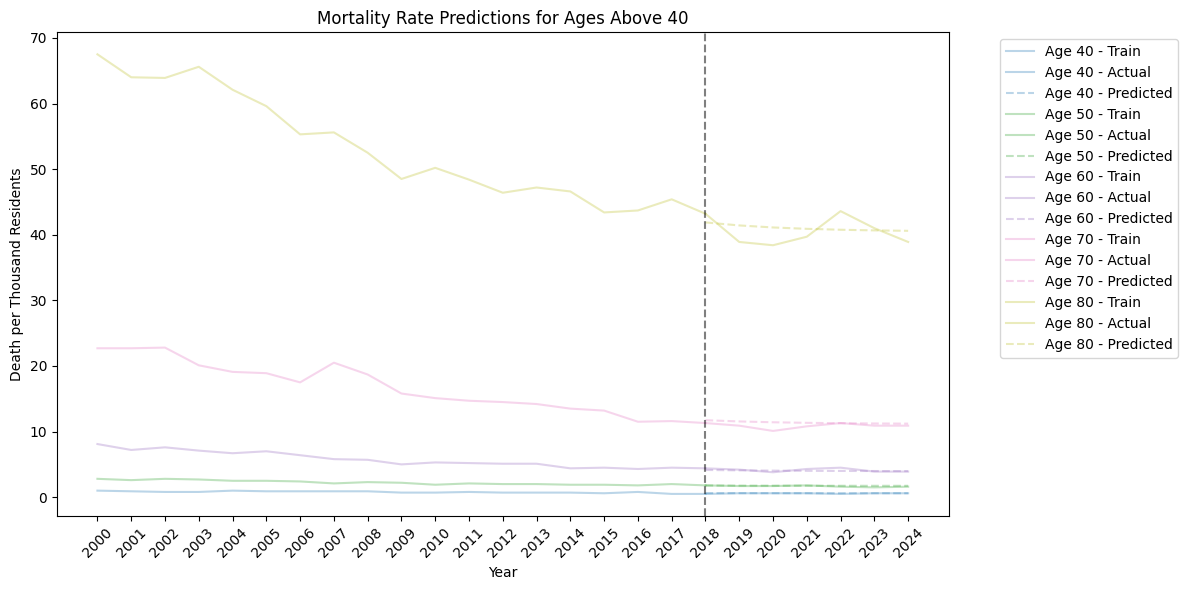

In [125]:

plt.figure(figsize=(12,6))
colors = plt.cm.tab10(np.linspace(0, 1, len(validation_data)))

plot_train_data = mortality_matrix.iloc[8:, :-6]  # 7 +1
for i, (idx, row) in enumerate(validation_data.iterrows()):
    if idx not in [9,11,13,15,17]:
        continue
        
    # Plot training data
    train_row = plot_train_data.iloc[i]
    plt.plot(plot_train_data.columns, train_row.values,
             label=f'Age {(idx-1)*5} - Train',
             color=colors[i],
             linestyle='-',
             alpha=0.3)
    
    # Plot validation actual values
    plt.plot(validation_data.columns, row.values, 
             label=f'Age {(idx-1)*5} - Actual', 
             color=colors[i],
             linestyle='-',
             alpha=0.3)
    
    # Plot predicted values
    plt.plot(validation_data.columns, mortality_pred[i], 
             label=f'Age {(idx-1)*5} - Predicted',
             color=colors[i], 
             linestyle='--',
             alpha=0.3)

plt.axvline(x='2018', color='black', linestyle='--', alpha=0.5)


plt.title('Mortality Rate Predictions for Ages Above 40')
plt.xlabel('Year')
plt.ylabel('Death per Thousand Residents')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### female , under 40

In [126]:

mortality_matrix = female_df.iloc[1:19,1:26]
mortality_matrix = mortality_matrix.iloc[:, ::-1]

# Split into training and validation sets
validation_years = 7  # Last 7 years for validation (2017-2023)
train_data = mortality_matrix.iloc[:, :-validation_years]  # Earlier years for training
validation_data = mortality_matrix.iloc[:, -validation_years:]  # Last 7 years for validation

# Only keep ages 40+ (rows 11-18) since Lee-Carter typically focuses on older ages
train_data = train_data.iloc[:8,:]
validation_data = validation_data.iloc[:8,:]

# Take log of mortality rates
log_train = np.log(train_data)
log_validation = np.log(validation_data)

# Fit Lee-Carter model
# Step 1: Calculate ax (average log mortality rate for each age)
ax = log_train.mean(axis=1)

# Step 2: Center the log mortality rates
centered = log_train.sub(ax, axis=0)

# Step 3: SVD decomposition
U, s, Vt = np.linalg.svd(centered, full_matrices=False)
bx = U[:, 0]  # First left singular vector
kt = s[0] * Vt[0, :]  # First right singular vector scaled by singular value

# Make predictions on validation set using ARIMA
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model to kt time series
# Using ARIMA(1,1,0) since data shows clear downward trend that needs differencing
# p=1 for autoregression, d=1 for differencing to handle trend, q=0 for simplicity
model = ARIMA(kt, order=(1,1,0))  # ARIMA with differencing is appropriate for trending data
fitted_model = model.fit()

# Generate predictions for validation period
kt_pred = fitted_model.forecast(steps=validation_years)
female_mortality_pred_under_40 = np.exp(ax.values.reshape(-1,1) + np.outer(bx, kt_pred))






In [127]:
validation_data

,2018,2019,2020,2021,2022,2023,2024
1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
2,0.1,0.1,0.1,0.1,0.1,0.1,0.1
3,0.1,0.1,0.1,0.1,0.1,0.1,0.1
4,0.1,0.1,0.1,0.3,0.1,0.2,0.3
5,0.2,0.1,0.2,0.2,0.2,0.1,0.2
6,0.2,0.2,0.2,0.2,0.1,0.2,0.2
7,0.3,0.3,0.2,0.2,0.3,0.2,0.2
8,0.4,0.3,0.4,0.4,0.5,0.4,0.4


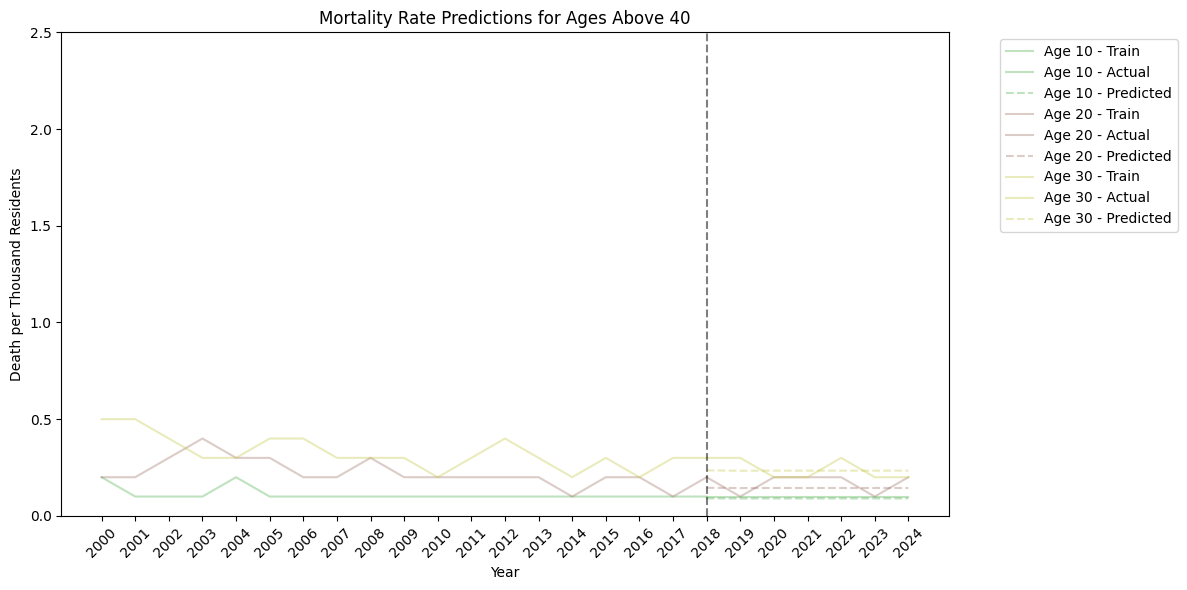

In [128]:

plt.figure(figsize=(12,6))
colors = plt.cm.tab10(np.linspace(0, 1, len(validation_data)))

plot_train_data = mortality_matrix.iloc[:8, :-6]  # 7 +1
for i, (idx, row) in enumerate(validation_data.iterrows()):
    if idx not in [3,5,7]:
        continue
        
    # Plot training data
    train_row = plot_train_data.iloc[i]
    plt.plot(plot_train_data.columns, train_row.values,
             label=f'Age {(idx-1)*5} - Train',
             color=colors[i],
             linestyle='-',
             alpha=0.3)
    
    # Plot validation actual values
    plt.plot(validation_data.columns, row.values, 
             label=f'Age {(idx-1)*5} - Actual', 
             color=colors[i],
             linestyle='-',
             alpha=0.3)
    
    # Plot predicted values
    plt.plot(validation_data.columns, female_mortality_pred_under_40[i], 
             label=f'Age {(idx-1)*5} - Predicted',
             color=colors[i], 
             linestyle='--',
             alpha=0.3)

plt.axvline(x='2018', color='black', linestyle='--', alpha=0.5)


plt.title('Mortality Rate Predictions for Ages Above 40')
plt.xlabel('Year')
plt.ylabel('Death per Thousand Residents')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.ylim(0,2.5)
plt.show()



In [129]:
mortality_matrix_list[1] = (female_mortality_pred_under_40)

## male mortality

In [130]:
male_df

,Data Series,2024,2023,2022,2021,2020,2019,2018,2017,2016,...,1989,1988,1987,1986,1985,1984,1983,1982,1981,1980
0,Under 1 Year,1.8,1.9,1.9,1.6,2.1,1.8,2.3,2.0,2.3,...,6.5,5.6,6,6.1,8.3,7.5,9.7,11.6,9,8.3
1,1 - 4 Years,0.1,0.2,0.2,0.1,0.1,0.1,0.1,0.1,0.2,...,0.3,0.4,0.4,0.4,0.3,0.7,0.6,0.6,0.5,0.7
2,5 - 9 Years,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,...,0.3,0.2,0.3,0.2,0.2,0.3,0.2,0.3,0.3,0.2
3,10 - 14 Years,0.1,0.2,0.2,0.1,0.1,0.1,0.1,0.1,0.2,...,0.3,0.2,0.3,0.3,0.3,0.3,0.4,0.4,0.3,0.3
4,15 - 19 Years,0.2,0.3,0.2,0.3,0.2,0.2,0.3,0.3,0.3,...,0.6,0.5,0.5,0.7,0.9,0.7,0.8,0.9,0.9,0.7
5,20 - 24 Years,0.4,0.4,0.4,0.3,0.3,0.4,0.4,0.3,0.3,...,0.7,0.9,0.8,0.9,0.8,1,1,1.1,0.9,1.2
6,25 - 29 Years,0.4,0.5,0.5,0.4,0.3,0.3,0.3,0.3,0.4,...,0.8,0.8,0.8,0.9,1,1,0.9,1,1.2,1.2
7,30 - 34 Years,0.5,0.5,0.5,0.4,0.4,0.4,0.5,0.5,0.4,...,1,0.9,1,1,1.2,1,1.1,1.2,1.1,1.3
8,35 - 39 Years,0.7,0.6,0.6,0.7,0.6,0.6,0.6,0.7,0.6,...,1.3,1.6,1.5,1.4,1.6,1.7,1.4,1.6,1.6,1.6
9,40 - 44 Years,1.0,1.0,1.1,1.0,1.0,1.0,0.9,1.1,1.1,...,2.3,2.4,2.2,2.4,2.3,2.6,2.7,2.7,2.6,2.9


In [131]:
mortality_matrix = male_df.iloc[1:19,1:26]
mortality_matrix = mortality_matrix.iloc[:, ::-1]

In [132]:
male_mortality_matrix = mortality_matrix

In [133]:
mortality_matrix

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1,0.3,0.3,0.2,0.2,0.2,0.2,0.1,0.1,0.1,0.2,...,0.2,0.2,0.1,0.1,0.1,0.1,0.1,0.2,0.2,0.1
2,0.1,0.1,0.1,0.2,0.1,0.1,0.1,0.1,0.1,0.1,...,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
3,0.3,0.1,0.1,0.2,0.1,0.1,0.2,0.1,0.1,0.2,...,0.1,0.2,0.1,0.1,0.1,0.1,0.1,0.2,0.2,0.1
4,0.3,0.4,0.3,0.5,0.3,0.3,0.2,0.2,0.3,0.3,...,0.2,0.3,0.3,0.3,0.2,0.2,0.3,0.2,0.3,0.2
5,0.7,0.7,0.6,0.8,0.7,0.6,0.5,0.6,0.4,0.5,...,0.3,0.3,0.3,0.4,0.4,0.3,0.3,0.4,0.4,0.4
6,0.6,0.7,0.6,0.6,0.4,0.5,0.5,0.7,0.5,0.5,...,0.4,0.4,0.3,0.3,0.3,0.3,0.4,0.5,0.5,0.4
7,0.8,0.7,0.6,0.8,0.7,0.6,0.6,0.5,0.5,0.6,...,0.5,0.4,0.5,0.5,0.4,0.4,0.4,0.5,0.5,0.5
8,1.3,1.0,1.1,0.9,0.9,1.0,0.9,0.9,0.9,0.8,...,0.7,0.6,0.7,0.6,0.6,0.6,0.7,0.6,0.6,0.7
9,1.8,1.6,1.6,1.6,1.6,1.5,1.6,1.5,1.4,1.2,...,1.1,1.1,1.1,0.9,1.0,1.0,1.0,1.1,1.0,1.0
10,2.7,2.5,2.7,2.7,2.4,2.4,2.3,2.3,2.4,2.0,...,1.9,1.7,1.7,1.8,1.7,1.6,1.9,1.8,1.7,1.7


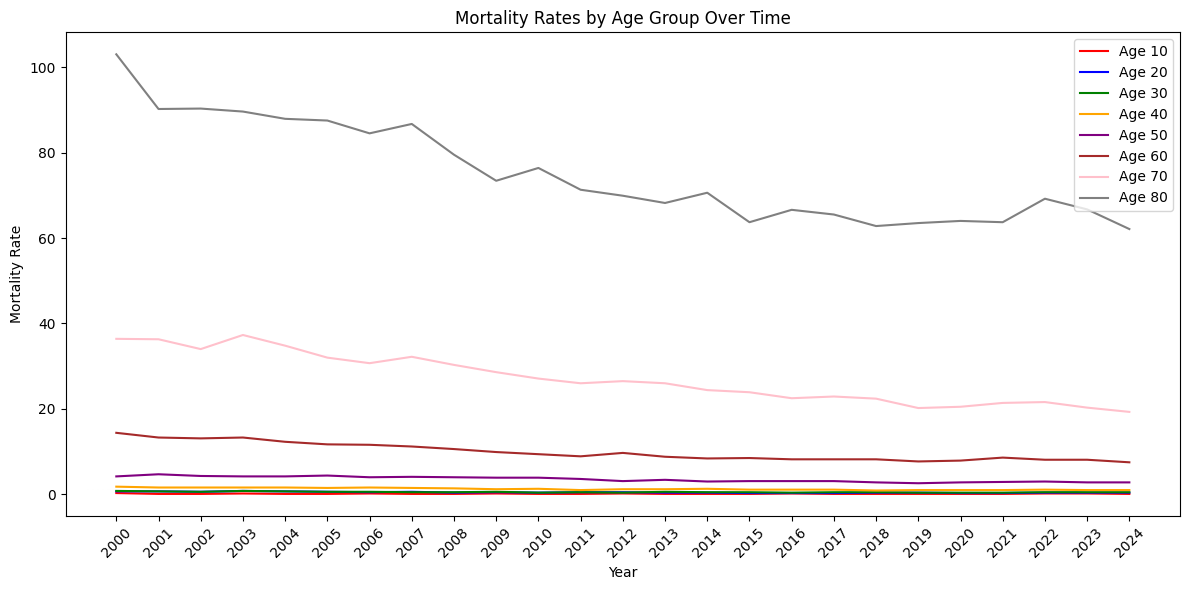

In [134]:
# Select odd-numbered rows starting from index 3
selected_rows = mortality_matrix.iloc[2::2]  # Rows 3,5,7,9...

# Create line plot
plt.figure(figsize=(12,6))

colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']

for i, (idx, row) in enumerate(selected_rows.iterrows()):
    age = (idx//2)*10   # Convert index to age group (3->40, 5->60, etc)
    plt.plot(row.index, row.values, label=f'Age {age}', color=colors[i])

plt.title('Mortality Rates by Age Group Over Time')
plt.xlabel('Year') 
plt.ylabel('Mortality Rate')
plt.legend()
plt.grid(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [135]:
mortality_matrix

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1,0.3,0.3,0.2,0.2,0.2,0.2,0.1,0.1,0.1,0.2,...,0.2,0.2,0.1,0.1,0.1,0.1,0.1,0.2,0.2,0.1
2,0.1,0.1,0.1,0.2,0.1,0.1,0.1,0.1,0.1,0.1,...,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
3,0.3,0.1,0.1,0.2,0.1,0.1,0.2,0.1,0.1,0.2,...,0.1,0.2,0.1,0.1,0.1,0.1,0.1,0.2,0.2,0.1
4,0.3,0.4,0.3,0.5,0.3,0.3,0.2,0.2,0.3,0.3,...,0.2,0.3,0.3,0.3,0.2,0.2,0.3,0.2,0.3,0.2
5,0.7,0.7,0.6,0.8,0.7,0.6,0.5,0.6,0.4,0.5,...,0.3,0.3,0.3,0.4,0.4,0.3,0.3,0.4,0.4,0.4
6,0.6,0.7,0.6,0.6,0.4,0.5,0.5,0.7,0.5,0.5,...,0.4,0.4,0.3,0.3,0.3,0.3,0.4,0.5,0.5,0.4
7,0.8,0.7,0.6,0.8,0.7,0.6,0.6,0.5,0.5,0.6,...,0.5,0.4,0.5,0.5,0.4,0.4,0.4,0.5,0.5,0.5
8,1.3,1.0,1.1,0.9,0.9,1.0,0.9,0.9,0.9,0.8,...,0.7,0.6,0.7,0.6,0.6,0.6,0.7,0.6,0.6,0.7
9,1.8,1.6,1.6,1.6,1.6,1.5,1.6,1.5,1.4,1.2,...,1.1,1.1,1.1,0.9,1.0,1.0,1.0,1.1,1.0,1.0
10,2.7,2.5,2.7,2.7,2.4,2.4,2.3,2.3,2.4,2.0,...,1.9,1.7,1.7,1.8,1.7,1.6,1.9,1.8,1.7,1.7


In [136]:
mortality_matrix = male_df.iloc[1:19,1:26]
mortality_matrix = mortality_matrix.iloc[:, ::-1]
# Split into training and validation sets
validation_years = 7  # Last 7 years for validation (2017-2023)
train_data = mortality_matrix.iloc[:, :-validation_years]  # Earlier years for training
validation_data = mortality_matrix.iloc[:, -validation_years:]  # Last 7 years for validation

# Only keep ages 55+ (rows 11-18) since Lee-Carter typically focuses on older ages
train_data = train_data.iloc[8:,:]
validation_data = validation_data.iloc[8:,:]

# Take log of mortality rates
log_train = np.log(train_data)


# Fit Lee-Carter model
# Step 1: Calculate ax (average log mortality rate for each age)
ax = log_train.mean(axis=1)

# Step 2: Center the log mortality rates
centered = log_train.sub(ax, axis=0)

# Step 3: SVD decomposition
U, s, Vt = np.linalg.svd(centered, full_matrices=False)
bx = U[:, 0]  # First left singular vector
kt = s[0] * Vt[0, :]  # First right singular vector scaled by singular value

# Make predictions on validation set using ARIMA
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model to kt time series
# Using ARIMA(1,1,0) since data shows clear downward trend that needs differencing
# p=1 for autoregression, d=1 for differencing to handle trend, q=0 for simplicity
model = ARIMA(kt, order=(1,1,0))  # ARIMA with differencing is appropriate for trending data
fitted_model = model.fit()

# Generate predictions for validation period
kt_pred = fitted_model.forecast(steps=validation_years)
male_mortality_pred = np.exp(ax.values.reshape(-1,1) + np.outer(bx, kt_pred))






In [137]:
mortality_matrix_list[2] =(male_mortality_pred)

In [138]:
# Calculate MAPE
mape = np.mean(np.abs((validation_data.values - male_mortality_pred) / validation_data.values)) * 100

# Calculate MAE 
mae = np.mean(np.abs(validation_data.values - male_mortality_pred)) 

# Calculate MAPE and MAE except year 2021 and 2022
# Exclude 4th and 5th columns (2021 and 2022) from calculations
validation_mask = np.ones(validation_data.shape[1], dtype=bool)
validation_mask[3:5] = False  # Set 4th and 5th columns to False

calibrated_mape = np.mean(np.abs((validation_data.values[:, validation_mask] - mortality_pred[:, validation_mask]) / validation_data.values[:, validation_mask])) * 100
calibrated_mae = np.mean(np.abs(validation_data.values[:, validation_mask] - mortality_pred[:, validation_mask])) 

print("\nMean Absolute Percentage Error on validation set: {:.2f}%".format(mape))
print("Mean Absolute Error on validation set: {:.2f}".format(mae))
print("\nCalibrated Mean Absolute Percentage Error (excluding 2021-2022): {:.2f}%".format(calibrated_mape))
print("Calibrated Mean Absolute Error (excluding 2021-2022): {:.2f}".format(calibrated_mae))


Mean Absolute Percentage Error on validation set: 6.12%
Mean Absolute Error on validation set: 1.69

Calibrated Mean Absolute Percentage Error (excluding 2021-2022): 38.53%
Calibrated Mean Absolute Error (excluding 2021-2022): 8.36


In [139]:
len(mortality_matrix_list)


4

In [140]:
mape = np.mean(np.abs((validation_data.values - mortality_pred) / validation_data.values), axis=0) * 100

In [141]:
mae = np.mean(np.abs(validation_data.values - mortality_pred), axis=0)

In [142]:
mape

array([38.21364712, 36.88280016, 38.15451181, 42.16031987, 43.45418174,
       41.2402532 , 38.17872462])

In [143]:
mae

array([ 8.00426438,  7.66469326,  8.04971543, 10.16757082, 12.08037374,
       10.056234  ,  8.01061032])

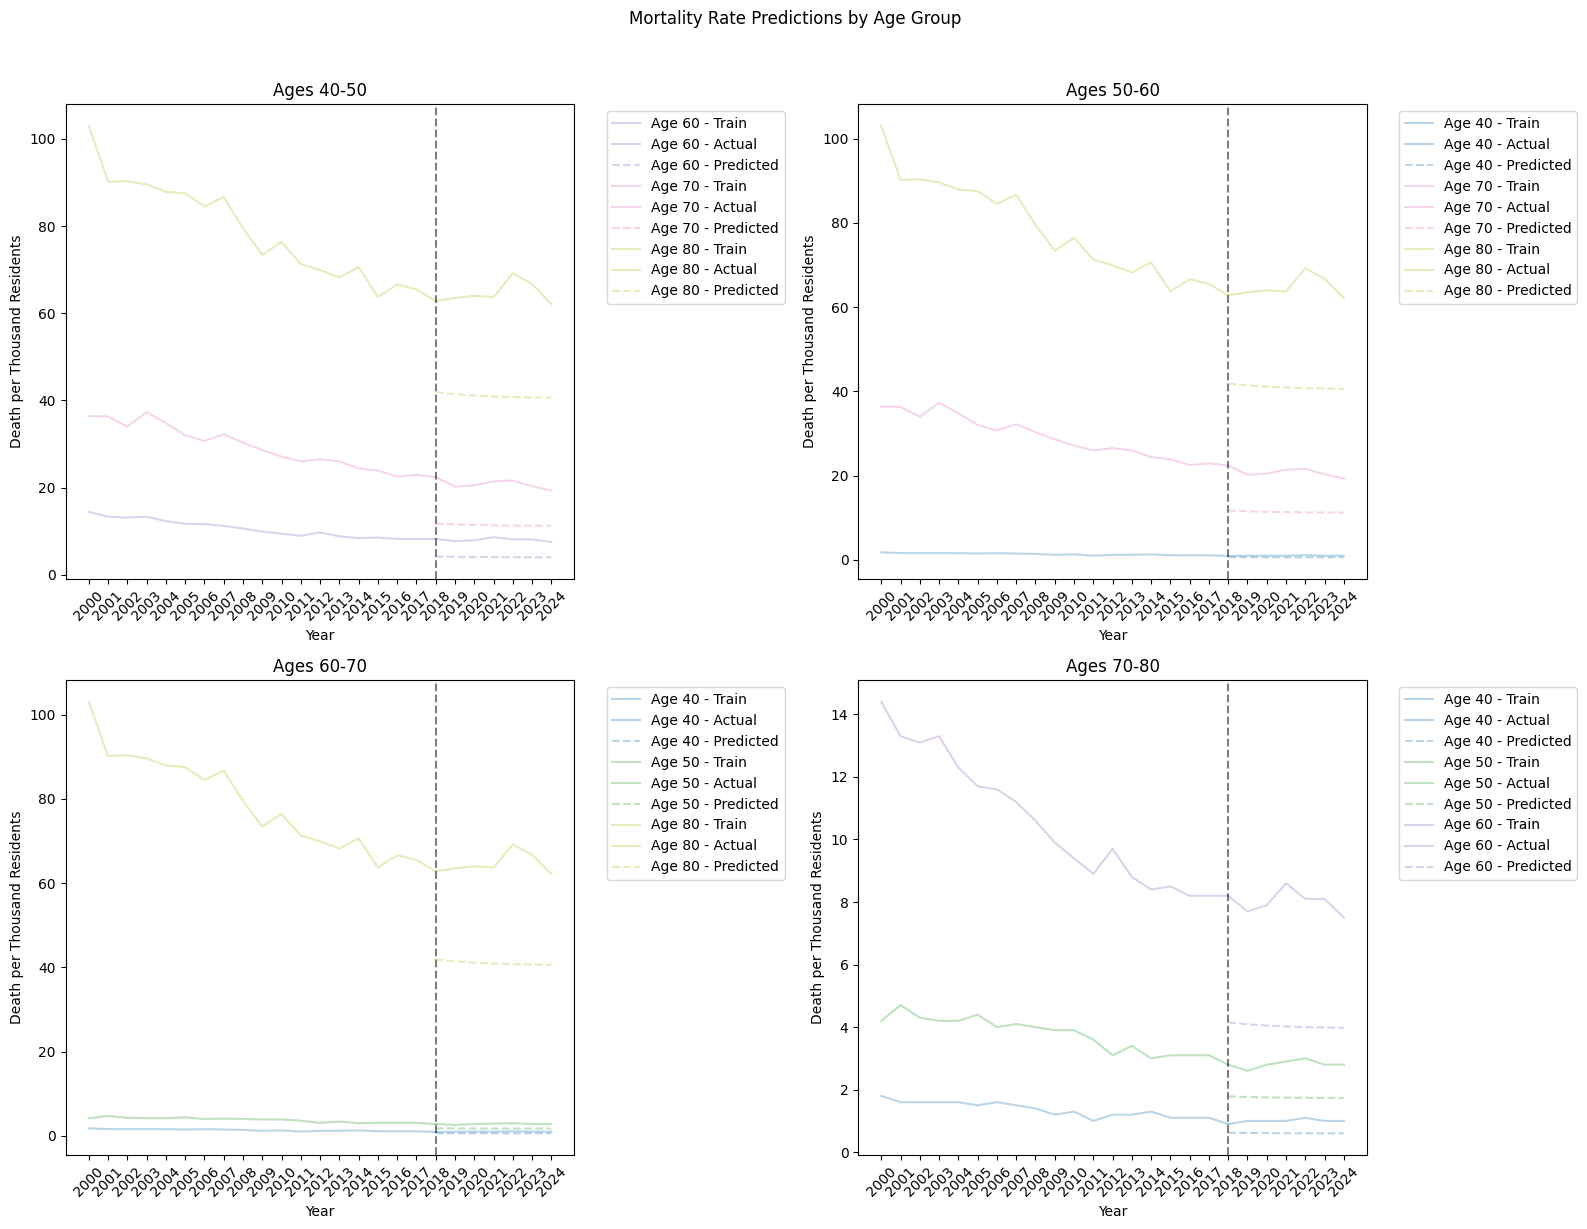

In [144]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors = plt.cm.tab10(np.linspace(0, 1, len(validation_data)))

plot_train_data = mortality_matrix.iloc[8:, :-6]  # 7 +1

# Plot configurations for each subplot
plot_configs = [
    {'exclude': [9,11], 'pos': (0,0), 'title': 'Ages 40-50'},
    {'exclude': [11,13], 'pos': (0,1), 'title': 'Ages 50-60'}, 
    {'exclude': [13,15], 'pos': (1,0), 'title': 'Ages 60-70'},
    {'exclude': [15,17], 'pos': (1,1), 'title': 'Ages 70-80'}
]

for config in plot_configs:
    ax = axes[config['pos']]
    
    for i, (idx, row) in enumerate(validation_data.iterrows()):
        if idx not in [9,11,13,15,17] or idx in config['exclude']:
            continue
            
        # Plot training data
        train_row = plot_train_data.iloc[i]
        ax.plot(plot_train_data.columns, train_row.values,
                label=f'Age {(idx-1)*5} - Train',
                color=colors[i],
                linestyle='-',
                alpha=0.3)
        
        # Plot validation actual values
        ax.plot(validation_data.columns, row.values, 
                label=f'Age {(idx-1)*5} - Actual', 
                color=colors[i],
                linestyle='-',
                alpha=0.3)
        
        # Plot predicted values
        ax.plot(validation_data.columns, mortality_pred[i], 
                label=f'Age {(idx-1)*5} - Predicted',
                color=colors[i], 
                linestyle='--',
                alpha=0.3)

    ax.axvline(x='2018', color='black', linestyle='--', alpha=0.5)
    ax.set_title(config['title'])
    ax.set_xlabel('Year')
    ax.set_ylabel('Death per Thousand Residents')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(False)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Mortality Rate Predictions by Age Group', y=1.02)
plt.tight_layout()
plt.show()

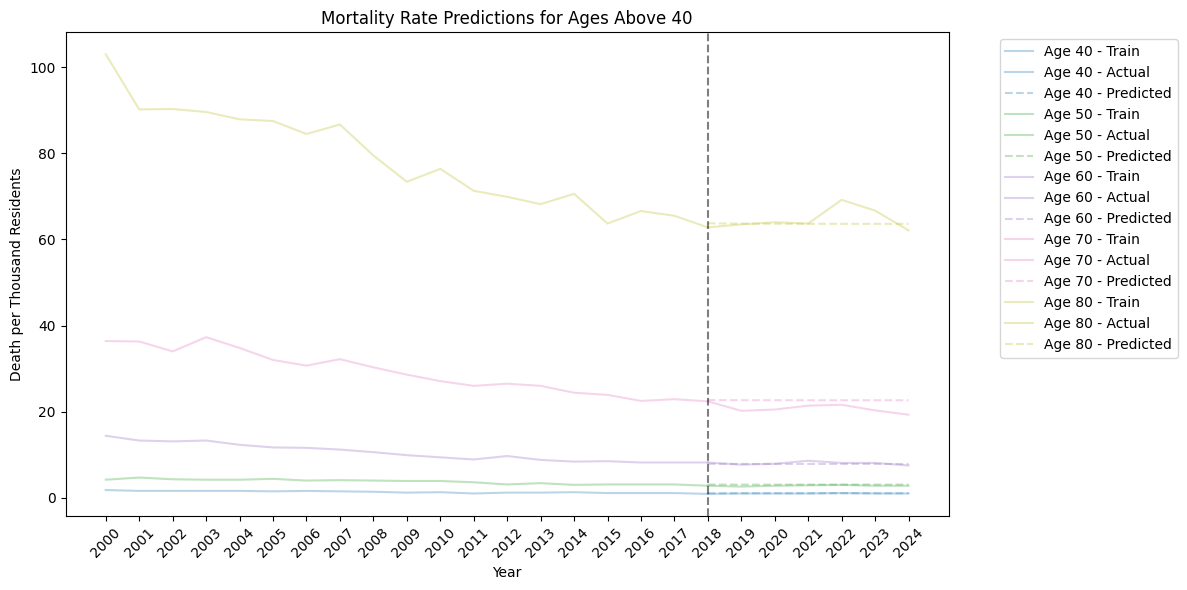

In [145]:

plt.figure(figsize=(12,6))
colors = plt.cm.tab10(np.linspace(0, 1, len(validation_data)))

plot_train_data = mortality_matrix.iloc[8:, :-6]  # 7 +1
for i, (idx, row) in enumerate(validation_data.iterrows()):
    if idx not in [9,11,13,15,17]:
        continue
        
    # Plot training data
    train_row = plot_train_data.iloc[i]
    plt.plot(plot_train_data.columns, train_row.values,
             label=f'Age {(idx-1)*5} - Train',
             color=colors[i],
             linestyle='-',
             alpha=0.3)
    
    # Plot validation actual values
    plt.plot(validation_data.columns, row.values, 
             label=f'Age {(idx-1)*5} - Actual', 
             color=colors[i],
             linestyle='-',
             alpha=0.3)
    
    # Plot predicted values
    plt.plot(validation_data.columns, male_mortality_pred[i], 
             label=f'Age {(idx-1)*5} - Predicted',
             color=colors[i], 
             linestyle='--',
             alpha=0.3)

plt.axvline(x='2018', color='black', linestyle='--', alpha=0.5)


plt.title('Mortality Rate Predictions for Ages Above 40')
plt.xlabel('Year')
plt.ylabel('Death per Thousand Residents')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [146]:
mortality_pred

array([[  0.6221334 ,   0.61554112,   0.61109121,   0.60807884,
          0.60603565,   0.60464799,   0.60370468],
       [  1.07122892,   1.06123659,   1.05448431,   1.04991001,
          1.04680585,   1.04469689,   1.04326293],
       [  1.78383543,   1.76556902,   1.75323513,   1.74488398,
          1.73921888,   1.73537095,   1.73275504],
       [  2.83854978,   2.80907317,   2.78917233,   2.77569882,
          2.7665594 ,   2.76035186,   2.75613193],
       [  4.15088695,   4.08965981,   4.04847638,   4.02066438,
          4.00183133,   3.98905482,   3.98037622],
       [  6.66145925,   6.54765332,   6.4712562 ,   6.41973372,
          6.38487725,   6.36124522,   6.34519974],
       [ 11.73644795,  11.54725572,  11.4201475 ,  11.33437714,
         11.27632876,  11.23696281,  11.2102297 ],
       [ 22.54310849,  22.2291542 ,  22.01782951,  21.87504938,
         21.77833349,  21.71270606,  21.66812103],
       [ 41.878307  ,  41.42048501,  41.11153505,  40.90243221,
         40.7606

In [147]:
validation_data

,2018,2019,2020,2021,2022,2023,2024
9,0.9,1.0,1.0,1.0,1.1,1.0,1.0
10,1.8,1.7,1.6,1.9,1.8,1.7,1.7
11,2.8,2.6,2.8,2.9,3.0,2.8,2.8
12,5.0,4.5,4.7,5.1,4.6,4.9,4.5
13,8.2,7.7,7.9,8.6,8.1,8.1,7.5
14,12.5,11.9,12.0,12.6,13.2,13.5,12.6
15,22.4,20.2,20.5,21.4,21.6,20.3,19.3
16,35.9,35.3,35.5,36.0,36.9,35.6,32.3
17,62.8,63.5,64.0,63.7,69.2,66.7,62.1
18,123.4,122.2,123.3,140.5,152.8,137.1,127.2


In [148]:
validation_data.columns

Index(['2018', '2019', '2020', '2021', '2022', '2023', '2024'], dtype='object')

ValueError: num must be an integer with 1 <= num <= 8, not 9

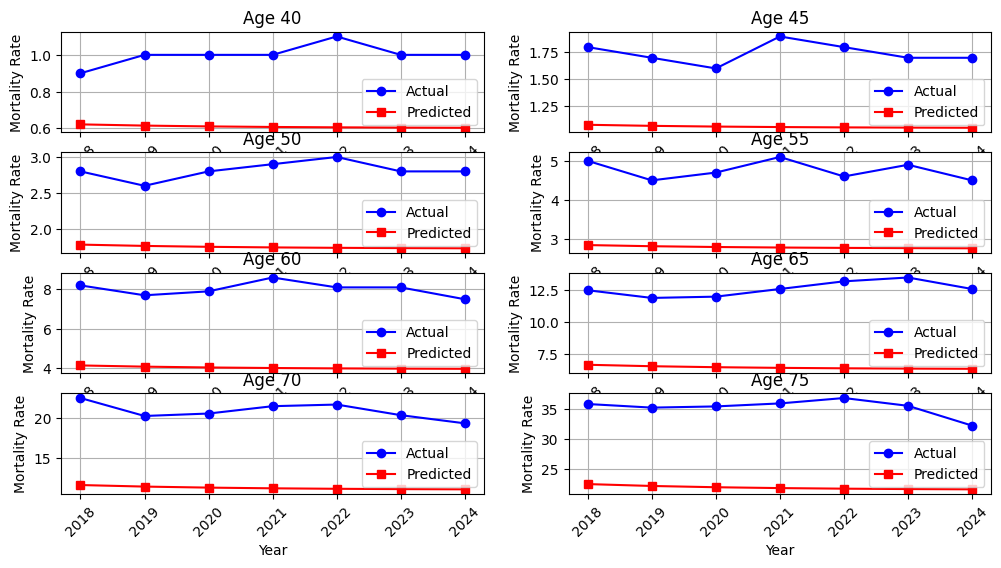

In [ ]:
# plt.figure(figsize=(12,6))
# colors = plt.cm.tab10(np.linspace(0, 1, len(validation_data)))

# # Plot each age group separately
# for i, (idx, row) in enumerate(validation_data.iterrows()):
#     age = (idx-1)*5
    
#     # Create subplot for this age group
#     plt.subplot(4,2,i+1)
    
#     # Plot validation actual values
#     plt.plot(validation_data.columns, row.values,
#              label='Actual',
#              color='blue',
#              marker='o')
    
#     # Plot predicted values 
#     plt.plot(validation_data.columns, mortality_pred[i],
#              label='Predicted',
#              color='red',
#              marker='s')
    
#     plt.title(f'Age {age}')
#     plt.xlabel('Year')
#     plt.ylabel('Mortality Rate')
#     plt.legend()
#     plt.grid(True)
#     plt.xticks(rotation=45)

# plt.suptitle('Actual vs Predicted Mortality Rates by Age Group')
# plt.tight_layout()

In [150]:
mortality_pred

array([[  0.6221334 ,   0.61554112,   0.61109121,   0.60807884,
          0.60603565,   0.60464799,   0.60370468],
       [  1.07122892,   1.06123659,   1.05448431,   1.04991001,
          1.04680585,   1.04469689,   1.04326293],
       [  1.78383543,   1.76556902,   1.75323513,   1.74488398,
          1.73921888,   1.73537095,   1.73275504],
       [  2.83854978,   2.80907317,   2.78917233,   2.77569882,
          2.7665594 ,   2.76035186,   2.75613193],
       [  4.15088695,   4.08965981,   4.04847638,   4.02066438,
          4.00183133,   3.98905482,   3.98037622],
       [  6.66145925,   6.54765332,   6.4712562 ,   6.41973372,
          6.38487725,   6.36124522,   6.34519974],
       [ 11.73644795,  11.54725572,  11.4201475 ,  11.33437714,
         11.27632876,  11.23696281,  11.2102297 ],
       [ 22.54310849,  22.2291542 ,  22.01782951,  21.87504938,
         21.77833349,  21.71270606,  21.66812103],
       [ 41.878307  ,  41.42048501,  41.11153505,  40.90243221,
         40.7606

In [151]:
validation_data

,2018,2019,2020,2021,2022,2023,2024
9,0.9,1.0,1.0,1.0,1.1,1.0,1.0
10,1.8,1.7,1.6,1.9,1.8,1.7,1.7
11,2.8,2.6,2.8,2.9,3.0,2.8,2.8
12,5.0,4.5,4.7,5.1,4.6,4.9,4.5
13,8.2,7.7,7.9,8.6,8.1,8.1,7.5
14,12.5,11.9,12.0,12.6,13.2,13.5,12.6
15,22.4,20.2,20.5,21.4,21.6,20.3,19.3
16,35.9,35.3,35.5,36.0,36.9,35.6,32.3
17,62.8,63.5,64.0,63.7,69.2,66.7,62.1
18,123.4,122.2,123.3,140.5,152.8,137.1,127.2


# for age smaller than 50 

In [152]:
mortality_matrix

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1,0.3,0.3,0.2,0.2,0.2,0.2,0.1,0.1,0.1,0.2,...,0.2,0.2,0.1,0.1,0.1,0.1,0.1,0.2,0.2,0.1
2,0.1,0.1,0.1,0.2,0.1,0.1,0.1,0.1,0.1,0.1,...,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
3,0.3,0.1,0.1,0.2,0.1,0.1,0.2,0.1,0.1,0.2,...,0.1,0.2,0.1,0.1,0.1,0.1,0.1,0.2,0.2,0.1
4,0.3,0.4,0.3,0.5,0.3,0.3,0.2,0.2,0.3,0.3,...,0.2,0.3,0.3,0.3,0.2,0.2,0.3,0.2,0.3,0.2
5,0.7,0.7,0.6,0.8,0.7,0.6,0.5,0.6,0.4,0.5,...,0.3,0.3,0.3,0.4,0.4,0.3,0.3,0.4,0.4,0.4
6,0.6,0.7,0.6,0.6,0.4,0.5,0.5,0.7,0.5,0.5,...,0.4,0.4,0.3,0.3,0.3,0.3,0.4,0.5,0.5,0.4
7,0.8,0.7,0.6,0.8,0.7,0.6,0.6,0.5,0.5,0.6,...,0.5,0.4,0.5,0.5,0.4,0.4,0.4,0.5,0.5,0.5
8,1.3,1.0,1.1,0.9,0.9,1.0,0.9,0.9,0.9,0.8,...,0.7,0.6,0.7,0.6,0.6,0.6,0.7,0.6,0.6,0.7
9,1.8,1.6,1.6,1.6,1.6,1.5,1.6,1.5,1.4,1.2,...,1.1,1.1,1.1,0.9,1.0,1.0,1.0,1.1,1.0,1.0
10,2.7,2.5,2.7,2.7,2.4,2.4,2.3,2.3,2.4,2.0,...,1.9,1.7,1.7,1.8,1.7,1.6,1.9,1.8,1.7,1.7


In [153]:
train_data_50

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
1,0.3,0.3,0.2,0.2,0.2,0.2,0.1,0.1,0.1,0.2,0.2,0.2,0.2,0.1,0.1,0.2,0.2,0.1
2,0.1,0.1,0.1,0.2,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
3,0.3,0.1,0.1,0.2,0.1,0.1,0.2,0.1,0.1,0.2,0.1,0.1,0.2,0.1,0.1,0.1,0.2,0.1
4,0.3,0.4,0.3,0.5,0.3,0.3,0.2,0.2,0.3,0.3,0.2,0.2,0.2,0.3,0.3,0.2,0.3,0.3
5,0.7,0.7,0.6,0.8,0.7,0.6,0.5,0.6,0.4,0.5,0.4,0.5,0.5,0.4,0.4,0.3,0.3,0.3
6,0.6,0.7,0.6,0.6,0.4,0.5,0.5,0.7,0.5,0.5,0.4,0.4,0.4,0.3,0.3,0.4,0.4,0.3
7,0.8,0.7,0.6,0.8,0.7,0.6,0.6,0.5,0.5,0.6,0.4,0.5,0.4,0.6,0.5,0.5,0.4,0.5
8,1.3,1.0,1.1,0.9,0.9,1.0,0.9,0.9,0.9,0.8,0.8,0.7,0.6,0.6,0.7,0.7,0.6,0.7


In [154]:
# Split into training and validation sets
validation_years = 7  # Last 7 years for validation (2017-2023)
train_data_50 = mortality_matrix.iloc[:, :-validation_years]  # Earlier years for training
validation_data_50 = mortality_matrix.iloc[:, -validation_years:]  # Last 7 years for validation

# Only keep ages under 50 (rows 1-10)
train_data_50 = train_data_50.iloc[:8,:]
validation_data_50 = validation_data_50.iloc[:8,:]

# Take log of mortality rates
log_train_50 = np.log(train_data_50)
log_validation_50 = np.log(validation_data_50)

# Fit Lee-Carter model
# Step 1: Calculate ax (average log mortality rate for each age)
ax_50 = log_train_50.mean(axis=1)

# Step 2: Center the log mortality rates
centered_50 = log_train_50.sub(ax_50, axis=0)

# Step 3: SVD decomposition
U_50, s_50, Vt_50 = np.linalg.svd(centered_50, full_matrices=False)
bx_50 = U_50[:, 0]  # First left singular vector
kt_50 = s_50[0] * Vt_50[0, :]  # First right singular vector scaled by singular value

# Fit ARIMA model to kt time series
from statsmodels.tsa.arima.model import ARIMA
model_50 = ARIMA(kt_50, order=(1,1,0))  # MA(1) model for short-term fluctuations
fitted_model_50 = model_50.fit()

# Generate predictions for validation period
kt_pred_50 = fitted_model_50.forecast(steps=validation_years)
mortality_pred_50 = np.exp(ax_50.values.reshape(-1,1) + np.outer(bx_50, kt_pred_50))



In [155]:
mortality_matrix_list[3] = (mortality_pred_50)

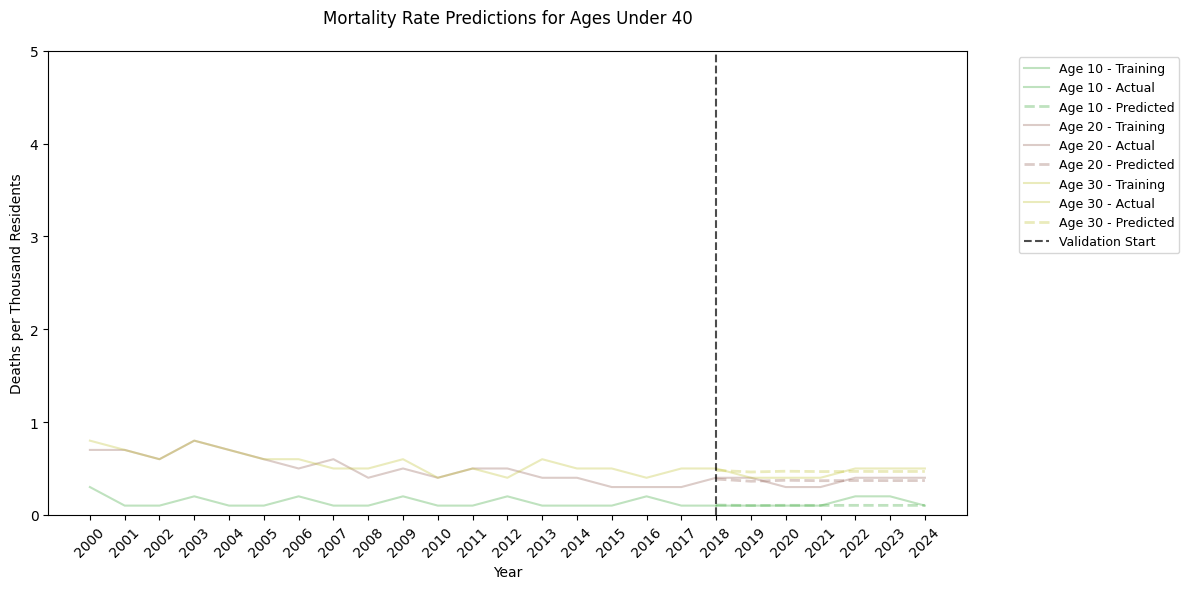

In [156]:
# Create figure
plt.figure(figsize=(12,6))

# Create custom colormap with more distinct colors
colors = plt.cm.tab10(np.linspace(0, 1, len(validation_data_50)))

#plot_train_data = mortality_matrix.iloc[:10, :-7]  # First 10 rows for ages under 50
plot_train_data = mortality_matrix.iloc[:8, :-6]
for i, (idx, row) in enumerate(validation_data_50.iterrows()):
    if idx not in [3,5,7]:  # Only plot every other age group to avoid crowding
        continue
        
    age = (idx-1)*5
    
    # Plot training data
    train_row = plot_train_data.iloc[i]
    plt.plot(plot_train_data.columns, train_row.values,
             label=f'Age {age} - Training',
             color=colors[i],
             linestyle='-',
             alpha=0.3)
    
    # Plot validation data with markers
    plt.plot(validation_data_50.columns, row.values, 
             label=f'Age {age} - Actual', 
             color=colors[i],
             linestyle='-',
             
             alpha=0.3)
    
    # Plot predictions with dashed line
    plt.plot(validation_data_50.columns, mortality_pred_50[i], 
             label=f'Age {age} - Predicted',
             color=colors[i], 
             linestyle='--',
             linewidth=2,
             alpha=0.3)

# Add vertical line for validation period start
plt.axvline(x='2018', color='black', linestyle='--', alpha=0.7, label='Validation Start')

plt.title('Mortality Rate Predictions for Ages Under 40', fontsize=12, pad=20)
plt.xlabel('Year', fontsize=10)
plt.ylabel('Deaths per Thousand Residents', fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(False)
plt.xticks(rotation=45)
plt.ylim(0,5)
# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()


In [157]:
# Save mortality_matrix_list to pickle file
import pickle

with open('mortality_matrix_list.pkl', 'wb') as f:
    pickle.dump(mortality_matrix_list, f)

# Read the pickle file back
with open('mortality_matrix_list.pkl', 'rb') as f:
    mortality_matrix_list = pickle.load(f)

mortality_matrix_list

[array([[  0.6221334 ,   0.61554112,   0.61109121,   0.60807884,
           0.60603565,   0.60464799,   0.60370468],
        [  1.07122892,   1.06123659,   1.05448431,   1.04991001,
           1.04680585,   1.04469689,   1.04326293],
        [  1.78383543,   1.76556902,   1.75323513,   1.74488398,
           1.73921888,   1.73537095,   1.73275504],
        [  2.83854978,   2.80907317,   2.78917233,   2.77569882,
           2.7665594 ,   2.76035186,   2.75613193],
        [  4.15088695,   4.08965981,   4.04847638,   4.02066438,
           4.00183133,   3.98905482,   3.98037622],
        [  6.66145925,   6.54765332,   6.4712562 ,   6.41973372,
           6.38487725,   6.36124522,   6.34519974],
        [ 11.73644795,  11.54725572,  11.4201475 ,  11.33437714,
          11.27632876,  11.23696281,  11.2102297 ],
        [ 22.54310849,  22.2291542 ,  22.01782951,  21.87504938,
          21.77833349,  21.71270606,  21.66812103],
        [ 41.878307  ,  41.42048501,  41.11153505,  40.90243221,

# panel plot

In [158]:
validation_data_ls = [0,0,0,0]
plot_train_data_ls = [0,0]
mortality_matrix = female_df.iloc[1:19,1:26]
mortality_matrix = mortality_matrix.iloc[:, ::-1]
validation_data = mortality_matrix.iloc[:, -7:]

validation_data_ls[0] = validation_data.iloc[8:,:]
validation_data_ls[1] = validation_data.iloc[:8,:]

plot_train_data_ls[0] = mortality_matrix

mortality_matrix = male_df.iloc[1:19,1:26]
mortality_matrix = mortality_matrix.iloc[:, ::-1]
validation_data = mortality_matrix.iloc[:, -7:]

validation_data_ls[2] = validation_data.iloc[8:,:]
validation_data_ls[3] = validation_data.iloc[:8,:]


plot_train_data_ls[1] = mortality_matrix

In [159]:
colors

array([[0.12156863, 0.46666667, 0.70588235, 1.        ],
       [1.        , 0.49803922, 0.05490196, 1.        ],
       [0.17254902, 0.62745098, 0.17254902, 1.        ],
       [0.58039216, 0.40392157, 0.74117647, 1.        ],
       [0.54901961, 0.3372549 , 0.29411765, 1.        ],
       [0.49803922, 0.49803922, 0.49803922, 1.        ],
       [0.7372549 , 0.74117647, 0.13333333, 1.        ],
       [0.09019608, 0.74509804, 0.81176471, 1.        ]])

In [160]:
colors = plt.cm.tab10(np.linspace(0, 1, len(plot_train_data_ls[0])))

In [161]:
for i in range(4):
    print(mortality_matrix_list[i].shape)

(10, 7)
(8, 7)
(10, 7)
(8, 7)


In [164]:
mortality_matrix_list[1].shape

(8, 7)

In [166]:
male_df = pd.read_pickle('preprocess_py/mortality_matrix_list.pkl')
male_df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'preprocess_py/mortality_matrix_list.pkl'

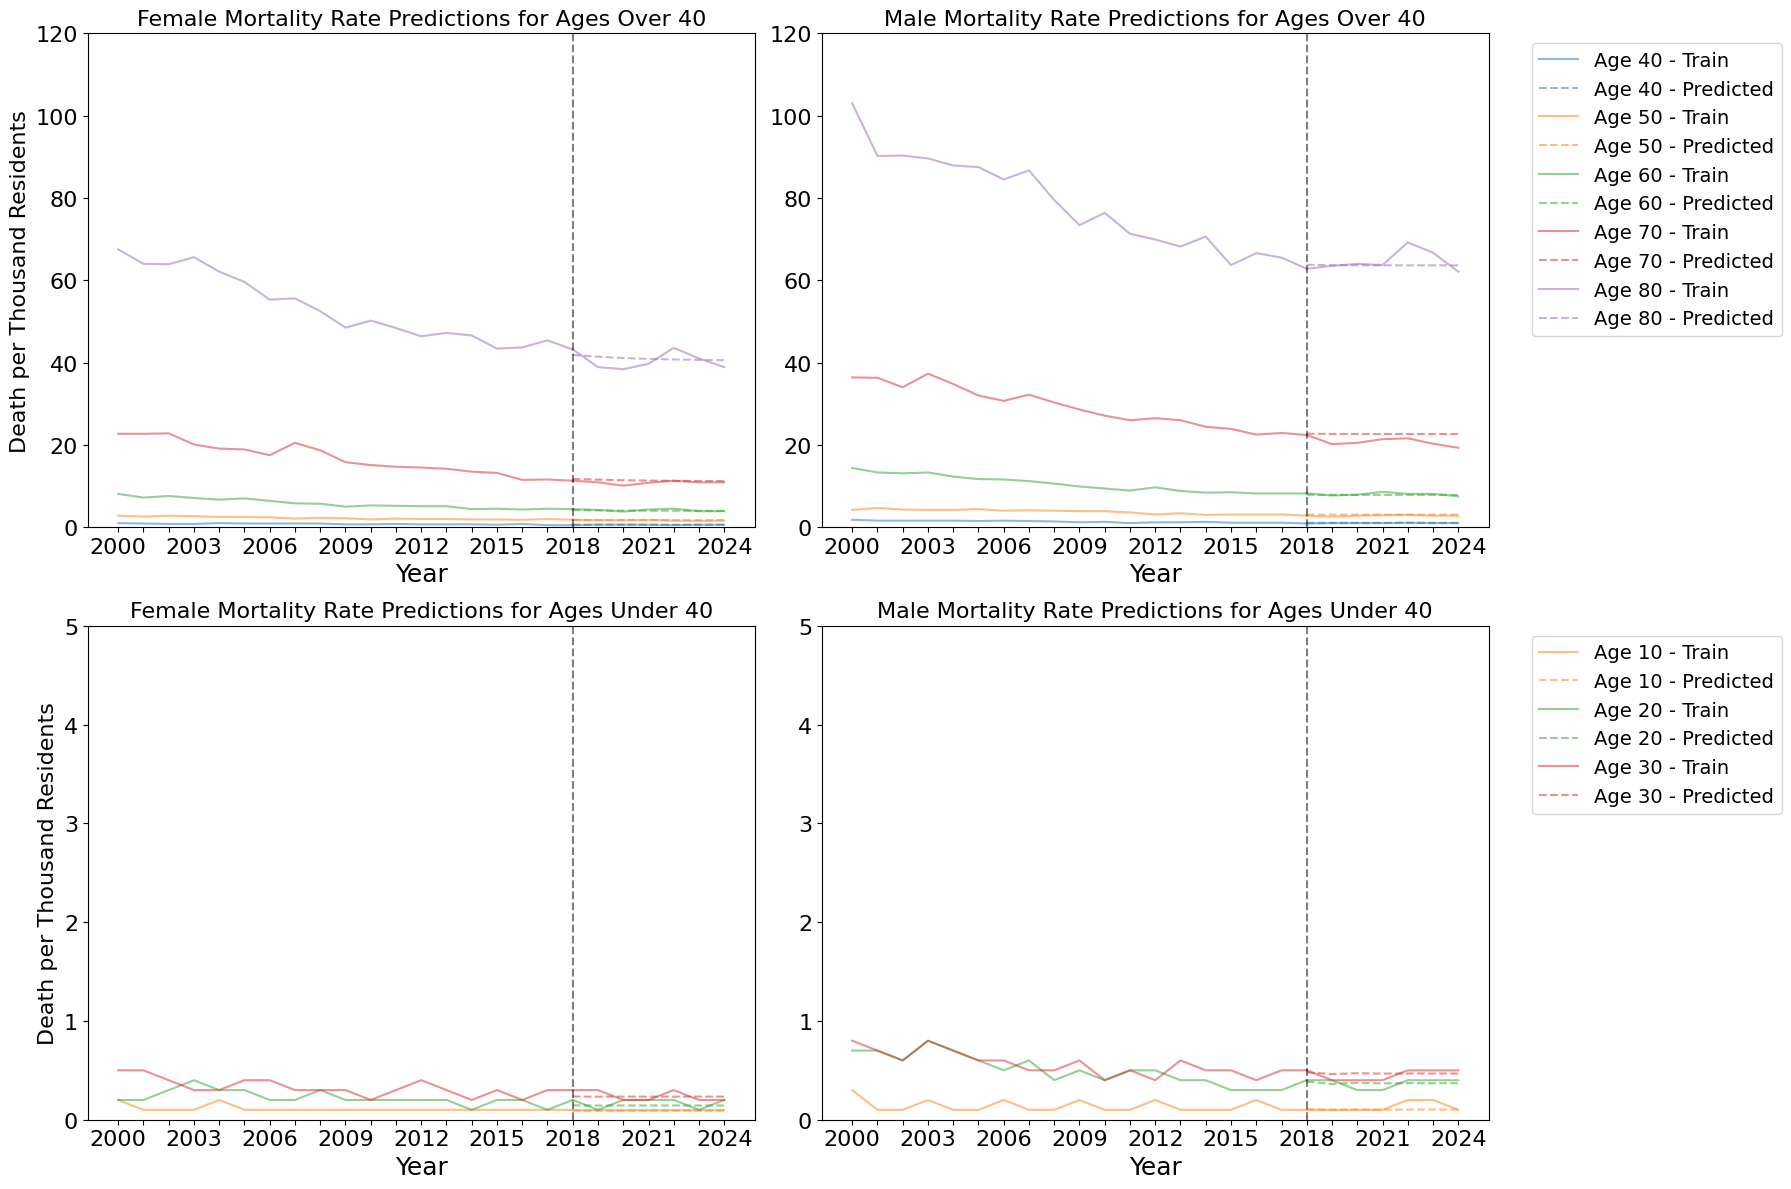

In [ ]:
# Create 2x2 panel plot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))
axes = [ax1,ax3,ax2, ax4]
titles = ['Female Mortality Rate Predictions for Ages Over 40',
          'Female Mortality Rate Predictions for Ages Under 40',
          'Male Mortality Rate Predictions for Ages Over 40', 
          'Male Mortality Rate Predictions for Ages Under 40']

colors = plt.cm.tab10(np.linspace(0, 1, len(plot_train_data_ls[0])))

for panel in range(4):
    ax = axes[panel]

    is_over_40 = panel % 2 == 0
    is_male = panel >= 2 
    
    data_idx = panel if not is_over_40 else panel-2
    if (is_over_40):
        plot_train_data = plot_train_data_ls[is_male].iloc[8:, :-6]
    else:
        plot_train_data = plot_train_data_ls[is_male].iloc[:8, :-6]
    
    for i, (idx, row) in enumerate(validation_data_ls[panel].iterrows()):
        if is_over_40:
            if idx not in [9,11,13,15,17]:
                continue
            matrix_idx = i
        else:
            if idx not in [3,5,7]:
                continue
            matrix_idx = i
            
        # Plot training data
        train_row = plot_train_data.iloc[i]
        ax.plot(plot_train_data.columns, train_row.values,
                label=f'Age {(idx-1)*5} - Train',
                color=colors[i],
                linestyle='-',
                alpha=0.5)

        # Plot validation actual values
        ax.plot(validation_data_ls[panel].columns, row.values,
                #label=f'Age {(idx-1)*5} - Actual',
                color=colors[i], 
                linestyle='-',
                alpha=0.5)

        # Plot predicted values
        ax.plot(validation_data_ls[panel].columns, mortality_matrix_list[panel][matrix_idx],
                label=f'Age {(idx-1)*5} - Predicted',
                color=colors[i],
                linestyle='--', 
                alpha=0.5)

    ax.axvline(x='2018', color='black', linestyle='--', alpha=0.5)
    ax.set_title(titles[panel], fontsize=16)
    ax.set_xlabel('Year', fontsize=18)
    if panel in [0,1]:
        ax.set_ylabel('Death per Thousand Residents', fontsize=16)
    if panel in [0,1]:
        ax.legend().remove()
    elif panel in [2,3]:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14)
    ax.grid(False)
    
    # Show every third x-label
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 3 != 0:
            label.set_visible(False)
        else:
            label.set_fontsize(10)
    
    ax.tick_params(axis='both', labelsize=16)
    
    if not is_over_40:
        ax.set_ylim(0, 5)
    else:
        ax.set_ylim(0, 120)

plt.tight_layout()
plt.show()




# forecasting


In [ ]:
mortality_fore_result = np.zeros((2, mortality_matrix.shape[0], 31))

In [ ]:
mortality_forecast.shape

(8, 31)

In [ ]:
# female
mortality_matrix = female_df.iloc[1:19,1:26]
mortality_matrix = mortality_matrix.iloc[:, ::-1]
mortality_matrix = mortality_matrix.iloc[:, :-5]
mortality_matrix



,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
1,0.3,0.2,0.1,0.2,0.2,0.2,0.1,0.1,0.2,0.2,0.1,0.1,0.1,0.2,0.1,0.1,0.1,0.1,0.1,0.1
2,0.2,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
3,0.2,0.1,0.1,0.1,0.2,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
4,0.2,0.3,0.3,0.2,0.3,0.1,0.2,0.2,0.1,0.2,0.1,0.2,0.2,0.2,0.2,0.2,0.1,0.1,0.1,0.1
5,0.2,0.2,0.3,0.4,0.3,0.3,0.2,0.2,0.3,0.2,0.2,0.2,0.2,0.2,0.1,0.2,0.2,0.1,0.2,0.1
6,0.3,0.2,0.3,0.3,0.2,0.2,0.3,0.2,0.3,0.2,0.2,0.2,0.2,0.2,0.1,0.2,0.2,0.2,0.2,0.2
7,0.5,0.5,0.4,0.3,0.3,0.4,0.4,0.3,0.3,0.3,0.2,0.3,0.4,0.3,0.2,0.3,0.2,0.3,0.3,0.3
8,0.7,0.6,0.7,0.6,0.5,0.5,0.5,0.4,0.5,0.4,0.5,0.4,0.5,0.4,0.3,0.4,0.3,0.3,0.4,0.3
9,1.0,0.9,0.8,0.8,1.0,0.9,0.9,0.9,0.9,0.7,0.7,0.8,0.7,0.7,0.7,0.6,0.8,0.5,0.5,0.6
10,1.7,1.5,1.5,1.5,1.5,1.4,1.4,1.4,1.2,1.3,1.2,1.3,1.3,1.1,1.2,1.1,1.1,1.1,1.0,0.9


In [ ]:
# do a forecasting for the future 31 years from 2020 to 2050
forecast_years = 31
total_train = mortality_matrix.iloc[8:,:]

# Take log of mortality rates
log_train = np.log(total_train)

# Fit Lee-Carter model
# Step 1: Calculate ax (average log mortality rate for each age)
ax = log_train.mean(axis=1)

# Step 2: Center the log mortality rates
centered = log_train.sub(ax, axis=0)

# Step 3: SVD decomposition
U, s, Vt = np.linalg.svd(centered, full_matrices=False)
bx = U[:, 0]  # First left singular vector
kt = s[0] * Vt[0, :]  # First right singular vector scaled by singular value

# Fit ARIMA model to kt time series
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(kt, order=(1,1,0))
fitted_model = model.fit()

# Generate predictions through 2050
kt_forecast = fitted_model.forecast(steps=forecast_years)
mortality_forecast = np.exp(ax.values.reshape(-1,1) + np.outer(bx, kt_forecast))

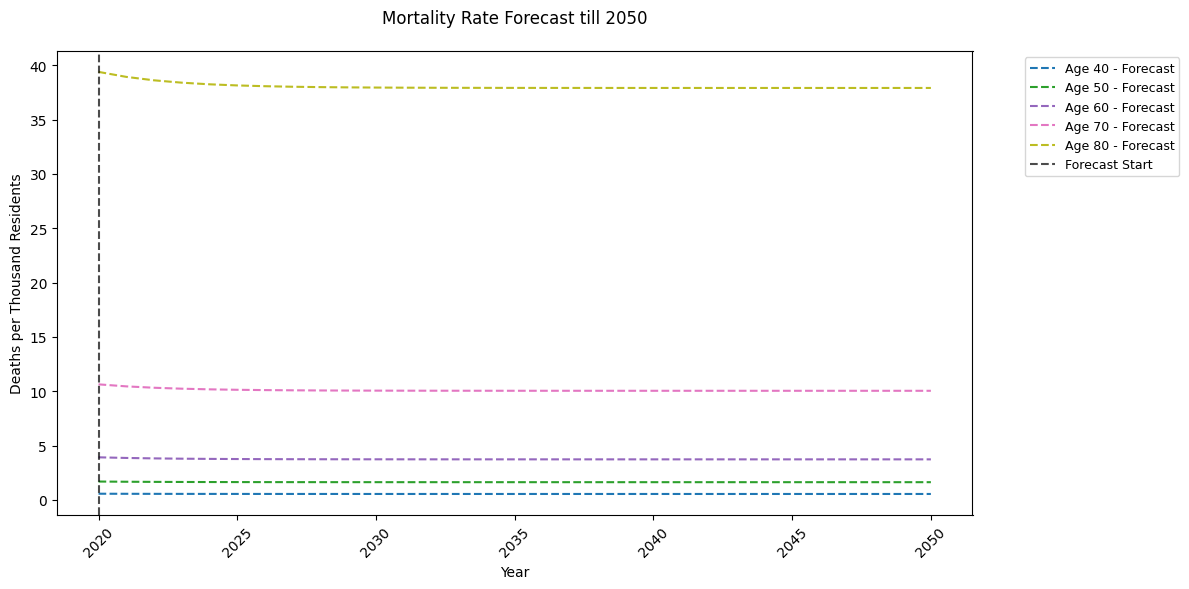

In [ ]:


# Create figure for forecast
plt.figure(figsize=(12,6))

# Create custom colormap
colors = plt.cm.tab10(np.linspace(0, 1, len(total_train)))

# Plot historical and forecasted data
years = np.arange(2020, 2051)
for i, (idx, row) in enumerate(total_train.iterrows()):
    if idx not in [9,11,13,15,17]:  # Only plot every other age group
        continue
        
    age = (idx-1)*5
    
    # Plot historical data
    # plt.plot(total_train.columns, row.values,
    #          label=f'Age {age} - Historical',
    #          color=colors[i],
    #          linestyle='-')
    
    # Plot forecasted data
    plt.plot(years, mortality_forecast[i], 
             label=f'Age {age} - Forecast',
             color=colors[i],
             linestyle='--')

plt.axvline(x=2020, color='black', linestyle='--', alpha=0.7, label='Forecast Start')

plt.title('Mortality Rate Forecast till 2050', fontsize=12, pad=20)
plt.xlabel('Year', fontsize=10)
plt.ylabel('Deaths per Thousand Residents', fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()










In [ ]:
mortality_forecast.shape

(10, 31)

In [ ]:
mortality_fore_result[1,8:,:] = mortality_forecast

# female below 40

In [ ]:
# do a forecasting for the future 31 years from 2020 to 2050
forecast_years = 31
total_train = mortality_matrix.iloc[:8,:]

# Take log of mortality rates
log_train = np.log(total_train)

# Fit Lee-Carter model
# Step 1: Calculate ax (average log mortality rate for each age)
ax = log_train.mean(axis=1)

# Step 2: Center the log mortality rates
centered = log_train.sub(ax, axis=0)

# Step 3: SVD decomposition
U, s, Vt = np.linalg.svd(centered, full_matrices=False)
bx = U[:, 0]  # First left singular vector
kt = s[0] * Vt[0, :]  # First right singular vector scaled by singular value

# Fit ARIMA model to kt time series
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(kt, order=(1,1,0))
fitted_model = model.fit()

# Generate predictions through 2050
kt_forecast = fitted_model.forecast(steps=forecast_years)
mortality_forecast = np.exp(ax.values.reshape(-1,1) + np.outer(bx, kt_forecast))

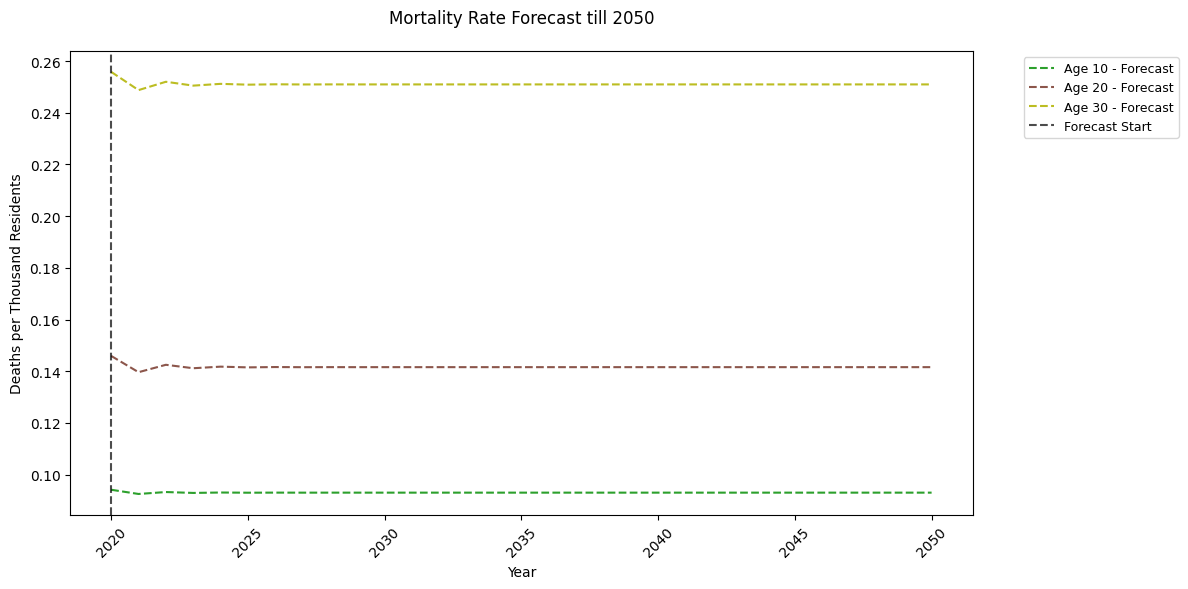

In [ ]:


# Create figure for forecast
plt.figure(figsize=(12,6))

# Create custom colormap
colors = plt.cm.tab10(np.linspace(0, 1, len(total_train)))

# Plot historical and forecasted data
years = np.arange(2020, 2051)
for i, (idx, row) in enumerate(total_train.iterrows()):
    if idx not in [3,5,7]:  # Only plot every other age group
        continue
        
    age = (idx-1)*5
    
    # Plot historical data
    # plt.plot(total_train.columns, row.values,
    #          label=f'Age {age} - Historical',
    #          color=colors[i],
    #          linestyle='-')
    
    # Plot forecasted data
    plt.plot(years, mortality_forecast[i], 
             label=f'Age {age} - Forecast',
             color=colors[i],
             linestyle='--')

plt.axvline(x=2020, color='black', linestyle='--', alpha=0.7, label='Forecast Start')

plt.title('Mortality Rate Forecast till 2050', fontsize=12, pad=20)
plt.xlabel('Year', fontsize=10)
plt.ylabel('Deaths per Thousand Residents', fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [ ]:
mortality_fore_result[1,:8,:] = mortality_forecast

# male above 40


In [ ]:
# female
mortality_matrix = male_df.iloc[1:19,1:26]
mortality_matrix = mortality_matrix.iloc[:, ::-1]
mortality_matrix = mortality_matrix.iloc[:, :-5]
mortality_matrix


,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
1,0.3,0.3,0.2,0.2,0.2,0.2,0.1,0.1,0.1,0.2,0.2,0.2,0.2,0.1,0.1,0.2,0.2,0.1,0.1,0.1
2,0.1,0.1,0.1,0.2,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
3,0.3,0.1,0.1,0.2,0.1,0.1,0.2,0.1,0.1,0.2,0.1,0.1,0.2,0.1,0.1,0.1,0.2,0.1,0.1,0.1
4,0.3,0.4,0.3,0.5,0.3,0.3,0.2,0.2,0.3,0.3,0.2,0.2,0.2,0.3,0.3,0.2,0.3,0.3,0.3,0.2
5,0.7,0.7,0.6,0.8,0.7,0.6,0.5,0.6,0.4,0.5,0.4,0.5,0.5,0.4,0.4,0.3,0.3,0.3,0.4,0.4
6,0.6,0.7,0.6,0.6,0.4,0.5,0.5,0.7,0.5,0.5,0.4,0.4,0.4,0.3,0.3,0.4,0.4,0.3,0.3,0.3
7,0.8,0.7,0.6,0.8,0.7,0.6,0.6,0.5,0.5,0.6,0.4,0.5,0.4,0.6,0.5,0.5,0.4,0.5,0.5,0.4
8,1.3,1.0,1.1,0.9,0.9,1.0,0.9,0.9,0.9,0.8,0.8,0.7,0.6,0.6,0.7,0.7,0.6,0.7,0.6,0.6
9,1.8,1.6,1.6,1.6,1.6,1.5,1.6,1.5,1.4,1.2,1.3,1.0,1.2,1.2,1.3,1.1,1.1,1.1,0.9,1.0
10,2.7,2.5,2.7,2.7,2.4,2.4,2.3,2.3,2.4,2.0,2.2,2.2,1.9,2.0,1.7,1.9,1.7,1.7,1.8,1.7


In [ ]:
# do a forecasting for the future 31 years from 2020 to 2050
forecast_years = 31
total_train = mortality_matrix.iloc[8:,:]

# Take log of mortality rates
log_train = np.log(total_train)

# Fit Lee-Carter model
# Step 1: Calculate ax (average log mortality rate for each age)
ax = log_train.mean(axis=1)

# Step 2: Center the log mortality rates
centered = log_train.sub(ax, axis=0)

# Step 3: SVD decomposition
U, s, Vt = np.linalg.svd(centered, full_matrices=False)
bx = U[:, 0]  # First left singular vector
kt = s[0] * Vt[0, :]  # First right singular vector scaled by singular value

# Fit ARIMA model to kt time series
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(kt, order=(1,1,0))
fitted_model = model.fit()

# Generate predictions through 2050
kt_forecast = fitted_model.forecast(steps=forecast_years)
mortality_forecast = np.exp(ax.values.reshape(-1,1) + np.outer(bx, kt_forecast))

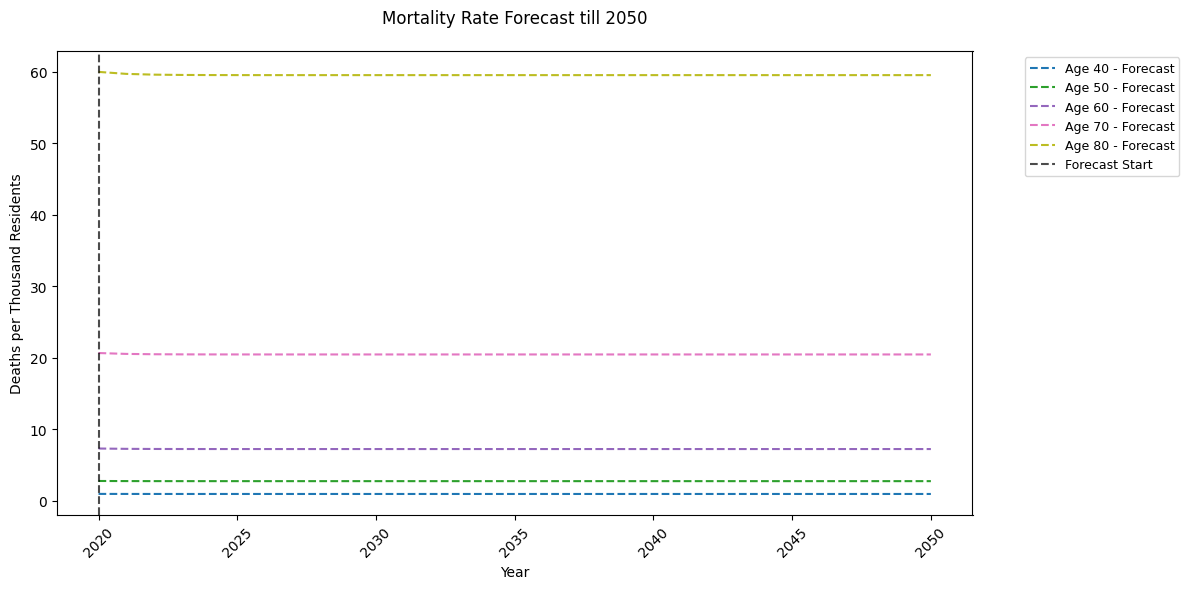

In [ ]:
# Create figure for forecast
plt.figure(figsize=(12,6))

# Create custom colormap
colors = plt.cm.tab10(np.linspace(0, 1, len(total_train)))

# Plot historical and forecasted data
years = np.arange(2020, 2051)
for i, (idx, row) in enumerate(total_train.iterrows()):
    if idx not in [9,11,13,15,17]:  # Only plot every other age group
        continue
        
    age = (idx-1)*5
    
    # Plot historical data
    # plt.plot(total_train.columns, row.values,
    #          label=f'Age {age} - Historical',
    #          color=colors[i],
    #          linestyle='-')
    
    # Plot forecasted data
    plt.plot(years, mortality_forecast[i], 
             label=f'Age {age} - Forecast',
             color=colors[i],
             linestyle='--')

plt.axvline(x=2020, color='black', linestyle='--', alpha=0.7, label='Forecast Start')

plt.title('Mortality Rate Forecast till 2050', fontsize=12, pad=20)
plt.xlabel('Year', fontsize=10)
plt.ylabel('Deaths per Thousand Residents', fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
mortality_fore_result[0,8:,:] = mortality_forecast

## male below 40

In [ ]:
# do a forecasting for the future 31 years from 2020 to 2050
forecast_years = 31
total_train = mortality_matrix.iloc[:8,:]

# Take log of mortality rates
log_train = np.log(total_train)

# Fit Lee-Carter model
# Step 1: Calculate ax (average log mortality rate for each age)
ax = log_train.mean(axis=1)

# Step 2: Center the log mortality rates
centered = log_train.sub(ax, axis=0)

# Step 3: SVD decomposition
U, s, Vt = np.linalg.svd(centered, full_matrices=False)
bx = U[:, 0]  # First left singular vector
kt = s[0] * Vt[0, :]  # First right singular vector scaled by singular value

# Fit ARIMA model to kt time series
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(kt, order=(1,1,0))
fitted_model = model.fit()

# Generate predictions through 2050
kt_forecast = fitted_model.forecast(steps=forecast_years)
mortality_forecast = np.exp(ax.values.reshape(-1,1) + np.outer(bx, kt_forecast))

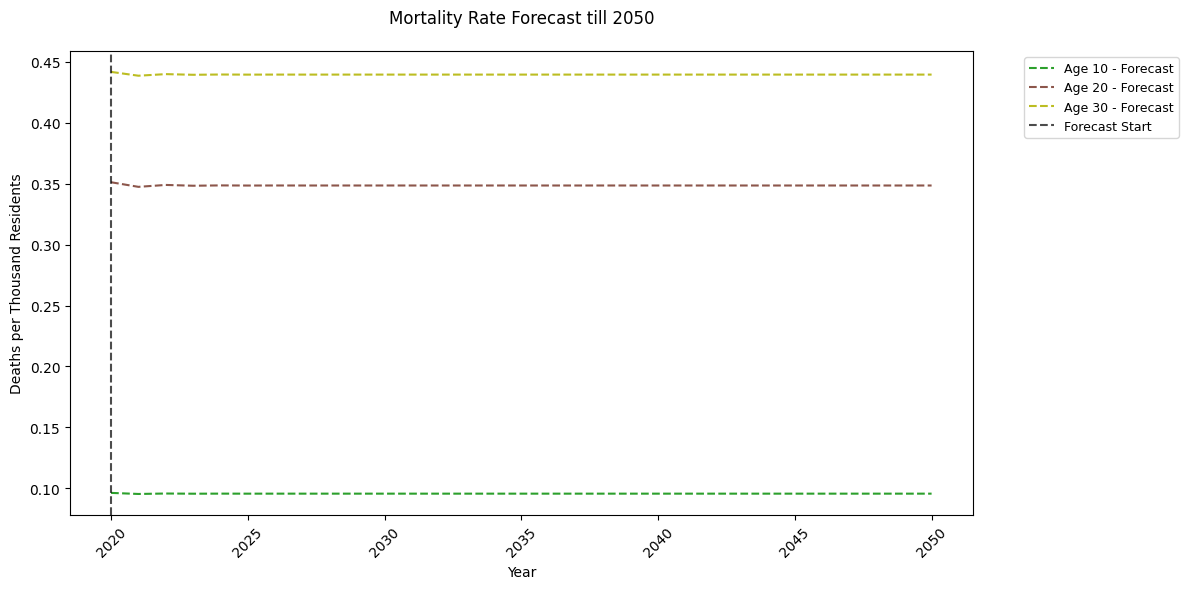

In [ ]:
# Create figure for forecast
plt.figure(figsize=(12,6))

# Create custom colormap
colors = plt.cm.tab10(np.linspace(0, 1, len(total_train)))

# Plot historical and forecasted data
years = np.arange(2020, 2051)
for i, (idx, row) in enumerate(total_train.iterrows()):
    if idx not in [3,5,7]:  # Only plot every other age group
        continue
        
    age = (idx-1)*5
    
    # Plot historical data
    # plt.plot(total_train.columns, row.values,
    #          label=f'Age {age} - Historical',
    #          color=colors[i],
    #          linestyle='-')
    
    # Plot forecasted data
    plt.plot(years, mortality_forecast[i], 
             label=f'Age {age} - Forecast',
             color=colors[i],
             linestyle='--')

plt.axvline(x=2020, color='black', linestyle='--', alpha=0.7, label='Forecast Start')

plt.title('Mortality Rate Forecast till 2050', fontsize=12, pad=20)
plt.xlabel('Year', fontsize=10)
plt.ylabel('Deaths per Thousand Residents', fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
mortality_fore_result[0,:8,:] = mortality_forecast

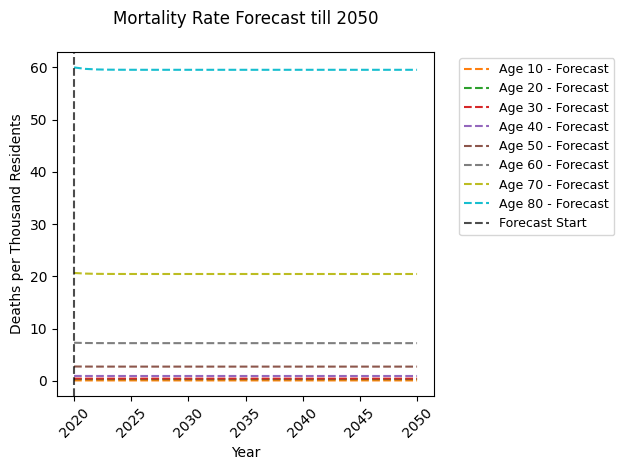

In [ ]:
# Plot historical and forecasted data
colors = plt.cm.tab10(np.linspace(0, 1, len(mortality_matrix)))
years = np.arange(2020, 2051)
for i, (idx, row) in enumerate(mortality_matrix.iterrows()):
    if idx not in [3,5,7,9,11,13,15,17]:  # Only plot every other age group
        continue
        
    age = (idx-1)*5
    
    # Plot historical data
    # plt.plot(total_train.columns, row.values,
    #          label=f'Age {age} - Historical',
    #          color=colors[i],
    #          linestyle='-')
    
    # Plot forecasted data
    plt.plot(years, mortality_fore_result[0,i,:], 
             label=f'Age {age} - Forecast',
             color=colors[i],
             linestyle='--')

plt.axvline(x=2020, color='black', linestyle='--', alpha=0.7, label='Forecast Start')

plt.title('Mortality Rate Forecast till 2050', fontsize=12, pad=20)
plt.xlabel('Year', fontsize=10)
plt.ylabel('Deaths per Thousand Residents', fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
mortality_fore_result[1, 4:, :].shape

(14, 31)

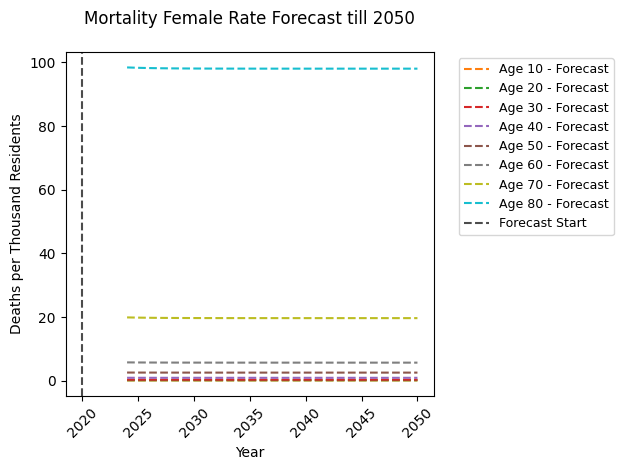

In [ ]:
# Plot historical and forecasted data
colors = plt.cm.tab10(np.linspace(0, 1, len(mortality_matrix)))
years = np.arange(2024, 2051)
for i, (idx, row) in enumerate(mortality_matrix.iterrows()):
    if idx not in [3,5,7,9,11,13,15,17]:  # Only plot every other age group
        continue
        
    age = (idx-1)*5
    
    # Plot historical data
    # plt.plot(total_train.columns, row.values,
    #          label=f'Age {age} - Historical',
    #          color=colors[i],
    #          linestyle='-')
    
    # Plot forecasted data
    plt.plot(years, mortality_fore_result[1, idx, 4:], 
             label=f'Age {age} - Forecast',
             color=colors[i],
             linestyle='--')

plt.axvline(x=2020, color='black', linestyle='--', alpha=0.7, label='Forecast Start')

plt.title('Mortality Female Rate Forecast till 2050', fontsize=12, pad=20)
plt.xlabel('Year', fontsize=10)
plt.ylabel('Deaths per Thousand Residents', fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
mortality_forecast_from_24 = mortality_fore_result[:, :, 4:]

In [ ]:
mortality_forecast_from_24.shape # 2024 - 2050 
# 1- 4, 5-9, 10 - 14, 15- 19, 20- 24,...80- 84,85 + 


(2, 18, 27)

In [ ]:
print("Data type of mortality_forecast_from_24:", mortality_forecast_from_24.dtype)
mortality_forecast_from_24

Data type of mortality_forecast_from_24: float64


array([[[1.04001079e-01, 1.03957241e-01, 1.03975442e-01, 1.03967884e-01,
         1.03971022e-01, 1.03969719e-01, 1.03970260e-01, 1.03970036e-01,
         1.03970129e-01, 1.03970090e-01, 1.03970106e-01, 1.03970100e-01,
         1.03970102e-01, 1.03970101e-01, 1.03970102e-01, 1.03970102e-01,
         1.03970102e-01, 1.03970102e-01, 1.03970102e-01, 1.03970102e-01,
         1.03970102e-01, 1.03970102e-01, 1.03970102e-01, 1.03970102e-01,
         1.03970102e-01, 1.03970102e-01, 1.03970102e-01],
        [9.53829176e-02, 9.53750211e-02, 9.53783000e-02, 9.53769385e-02,
         9.53775038e-02, 9.53772690e-02, 9.53773665e-02, 9.53773261e-02,
         9.53773429e-02, 9.53773359e-02, 9.53773388e-02, 9.53773376e-02,
         9.53773381e-02, 9.53773379e-02, 9.53773380e-02, 9.53773379e-02,
         9.53773379e-02, 9.53773379e-02, 9.53773379e-02, 9.53773379e-02,
         9.53773379e-02, 9.53773379e-02, 9.53773379e-02, 9.53773379e-02,
         9.53773379e-02, 9.53773379e-02, 9.53773379e-02],
        

In [ ]:
# Save mortality forecast data to binary file
np.save('mortality_forecast_from_24.npy', mortality_forecast_from_24)

# Read the saved data back
mortality_forecast_from_24 = np.load('mortality_forecast_from_24.npy')

In [ ]:
# Save mortality forecast data to binary file
with open('mortality_forecast_from_24.bin', 'wb') as f:
    mortality_forecast_from_24.tofile(f)



In [ ]:
# Read the saved data back 
with open('mortality_forecast_from_24.bin', 'rb') as f:
    mortality_forecast_from_24 = np.fromfile(f).reshape(2, 18, 27)

In [ ]:
mortality_forecast_from_24

array([1.04001079e-01, 1.03957241e-01, 1.03975442e-01, 1.03967884e-01,
       1.03971022e-01, 1.03969719e-01, 1.03970260e-01, 1.03970036e-01,
       1.03970129e-01, 1.03970090e-01, 1.03970106e-01, 1.03970100e-01,
       1.03970102e-01, 1.03970101e-01, 1.03970102e-01, 1.03970102e-01,
       1.03970102e-01, 1.03970102e-01, 1.03970102e-01, 1.03970102e-01,
       1.03970102e-01, 1.03970102e-01, 1.03970102e-01, 1.03970102e-01,
       1.03970102e-01, 1.03970102e-01, 1.03970102e-01, 9.53829176e-02,
       9.53750211e-02, 9.53783000e-02, 9.53769385e-02, 9.53775038e-02,
       9.53772690e-02, 9.53773665e-02, 9.53773261e-02, 9.53773429e-02,
       9.53773359e-02, 9.53773388e-02, 9.53773376e-02, 9.53773381e-02,
       9.53773379e-02, 9.53773380e-02, 9.53773379e-02, 9.53773379e-02,
       9.53773379e-02, 9.53773379e-02, 9.53773379e-02, 9.53773379e-02,
       9.53773379e-02, 9.53773379e-02, 9.53773379e-02, 9.53773379e-02,
       9.53773379e-02, 9.53773379e-02, 9.56295502e-02, 9.56031810e-02,
      

In [ ]:
mortality_forecast_from_24

array([[[1.04001079e-01, 1.03957241e-01, 1.03975442e-01, 1.03967884e-01,
         1.03971022e-01, 1.03969719e-01, 1.03970260e-01, 1.03970036e-01,
         1.03970129e-01, 1.03970090e-01, 1.03970106e-01, 1.03970100e-01,
         1.03970102e-01, 1.03970101e-01, 1.03970102e-01, 1.03970102e-01,
         1.03970102e-01, 1.03970102e-01, 1.03970102e-01, 1.03970102e-01,
         1.03970102e-01, 1.03970102e-01, 1.03970102e-01, 1.03970102e-01,
         1.03970102e-01, 1.03970102e-01, 1.03970102e-01],
        [9.53829176e-02, 9.53750211e-02, 9.53783000e-02, 9.53769385e-02,
         9.53775038e-02, 9.53772690e-02, 9.53773665e-02, 9.53773261e-02,
         9.53773429e-02, 9.53773359e-02, 9.53773388e-02, 9.53773376e-02,
         9.53773381e-02, 9.53773379e-02, 9.53773380e-02, 9.53773379e-02,
         9.53773379e-02, 9.53773379e-02, 9.53773379e-02, 9.53773379e-02,
         9.53773379e-02, 9.53773379e-02, 9.53773379e-02, 9.53773379e-02,
         9.53773379e-02, 9.53773379e-02, 9.53773379e-02],
        

In [ ]:
male_df # preprocess_py/mortality_matrix_list.pkl

,Data Series,2024,2023,2022,2021,2020,2019,2018,2017,2016,...,1989,1988,1987,1986,1985,1984,1983,1982,1981,1980
0,Under 1 Year,1.8,1.9,1.9,1.6,2.1,1.8,2.3,2.0,2.3,...,6.5,5.6,6,6.1,8.3,7.5,9.7,11.6,9,8.3
1,1 - 4 Years,0.1,0.2,0.2,0.1,0.1,0.1,0.1,0.1,0.2,...,0.3,0.4,0.4,0.4,0.3,0.7,0.6,0.6,0.5,0.7
2,5 - 9 Years,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,...,0.3,0.2,0.3,0.2,0.2,0.3,0.2,0.3,0.3,0.2
3,10 - 14 Years,0.1,0.2,0.2,0.1,0.1,0.1,0.1,0.1,0.2,...,0.3,0.2,0.3,0.3,0.3,0.3,0.4,0.4,0.3,0.3
4,15 - 19 Years,0.2,0.3,0.2,0.3,0.2,0.2,0.3,0.3,0.3,...,0.6,0.5,0.5,0.7,0.9,0.7,0.8,0.9,0.9,0.7
5,20 - 24 Years,0.4,0.4,0.4,0.3,0.3,0.4,0.4,0.3,0.3,...,0.7,0.9,0.8,0.9,0.8,1,1,1.1,0.9,1.2
6,25 - 29 Years,0.4,0.5,0.5,0.4,0.3,0.3,0.3,0.3,0.4,...,0.8,0.8,0.8,0.9,1,1,0.9,1,1.2,1.2
7,30 - 34 Years,0.5,0.5,0.5,0.4,0.4,0.4,0.5,0.5,0.4,...,1,0.9,1,1,1.2,1,1.1,1.2,1.1,1.3
8,35 - 39 Years,0.7,0.6,0.6,0.7,0.6,0.6,0.6,0.7,0.6,...,1.3,1.6,1.5,1.4,1.6,1.7,1.4,1.6,1.6,1.6
9,40 - 44 Years,1.0,1.0,1.1,1.0,1.0,1.0,0.9,1.1,1.1,...,2.3,2.4,2.2,2.4,2.3,2.6,2.7,2.7,2.6,2.9


# new born

In [ ]:
## for the new born mortality
infant_mortality = male_df.iloc[0,1:26][::-1]
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(infant_mortality.index, infant_mortality.values, marker='o')
plt.title('Infant Mortality Rates (2000-2024)')
plt.xlabel('Year')
plt.ylabel('Mortality Rate')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
import numpy as np
print(f"NumPy version: {np.__version__}")

print("Data type of train_data:", type(train_data))
print("\nFirst few values:")
print(train_data.head())
print("\nData type of values:", train_data.dtype)
train_data = pd.to_numeric(train_data)
np.log(train_data)
X_train
y_train
X_val
current_sequence = X_val
current_sequence[0][-1] =1
current_sequence
np.roll(current_sequence, -1)
# Split into training and validation sets
train_data = infant_mortality[:-8]
val_data = infant_mortality[-8:]

# Take log of values since we know it's decreasing
import numpy as np
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
# Prepare data
train_data = pd.to_numeric(train_data)
val_data = pd.to_numeric(val_data)

# Scale data between 0 and 1 for better ML performance
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data.values.reshape(-1, 1))
val_scaled = scaler.transform(val_data.values.reshape(-1, 1))

# Prepare sequences for time series prediction
def create_sequences(data, seq_length=3):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length), 0])
        y.append(data[i + seq_length, 0])
    return np.array(X), np.array(y)

seq_length = 3
X_train, y_train = create_sequences(train_scaled, seq_length)
X_val = train_scaled[-seq_length:].reshape(1, -1)

# Train models
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# SVR model
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train, y_train)

# Make predictions
rf_predictions = []
svr_predictions = []
current_sequence = X_val

for _ in range(len(val_data)):
    rf_pred = rf_model.predict(current_sequence)
    svr_pred = svr_model.predict(current_sequence)
    
    rf_predictions.append(rf_pred[0])
    svr_predictions.append(svr_pred[0])
    
    current_sequence = np.roll(current_sequence, -1)
    current_sequence[0][-1] = svr_pred[0]

# Inverse transform predictions
rf_predictions = scaler.inverse_transform(np.array(rf_predictions).reshape(-1, 1))
svr_predictions = scaler.inverse_transform(np.array(svr_predictions).reshape(-1, 1))

# Calculate MAPE
rf_val_mape = np.mean(np.abs((val_data.values - rf_predictions.flatten()) / val_data.values)) * 100
svr_val_mape = np.mean(np.abs((val_data.values - svr_predictions.flatten()) / val_data.values)) * 100

# Training predictions
rf_train_pred = rf_model.predict(X_train)
svr_train_pred = svr_model.predict(X_train)

rf_train_pred = scaler.inverse_transform(rf_train_pred.reshape(-1, 1))
svr_train_pred = scaler.inverse_transform(svr_train_pred.reshape(-1, 1))

# Calculate training MAPE
rf_train_mape = np.mean(np.abs((train_data.values[seq_length:] - rf_train_pred.flatten()) / train_data.values[seq_length:])) * 100
svr_train_mape = np.mean(np.abs((train_data.values[seq_length:] - svr_train_pred.flatten()) / train_data.values[seq_length:])) * 100

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(train_data.index[seq_length:], train_data.values[seq_length:], 'b-', label='Training Data')
plt.plot(val_data.index, val_data.values, 'g-', label='Validation Data')
plt.plot(val_data.index, rf_predictions, 'r--', label='RF Predictions')
plt.plot(val_data.index, svr_predictions, 'y--', label='SVR Predictions')
plt.title('Infant Mortality Rate Predictions')
plt.xlabel('Year')
plt.ylabel('Mortality Rate')
plt.legend()
plt.grid(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.ylim(1,3)
plt.show()


# Print error metrics
print("\nRandom Forest Model:")
print(f"Training MAPE: {rf_train_mape:.2f}%")
print(f"Validation MAPE: {rf_val_mape:.2f}%")

print("\nSVR Model:")
print(f"Training MAPE: {svr_train_mape:.2f}%")
print(f"Validation MAPE: {svr_val_mape:.2f}%")

# Support Vector Regression

male_df.iloc[:24,1:24]

store to numpy file 